## What I want to understand in this stage

The main questions I am checking are:

- Which predictor influenced the selected model most?
- Did a higher previous collision count increase the hotspot prediction?
- Did being a hotspot in the previous year increase the next-year prediction?
- Why were some predictions correct?
- Why did the model produce false positives and false negatives?
- Do the model explanations broadly agree with the earlier Stage 7 statistical results?

The explanations in this notebook describe the behaviour of the fitted model. They do not prove that a variable causes road traffic collision hotspots.

## A small note before starting

I do not know in advance which Stage 8 model was selected, so I will first inspect the saved performance tables and the saved model object.

I will start with simpler interpretation such as coefficients or feature importance. After that, I will try SHAP.

## 1. Mount Google Drive

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import the libraries I need at the start

In [86]:
import os
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

## 3. Set the file paths

I am keeping all new outputs inside a separate Stage 9 folder so that I do not overwrite anything from Stage 8.

In [87]:
project_path = Path("/content/drive/MyDrive/disseration")

stage7_path = project_path / "stage7_outputs"
stage8_path = project_path / "stage8_outputs"
stage9_path = project_path / "stage9_outputs"

model_file = stage8_path / "models" / "stage8_selected_model.joblib"
scaler_file = stage8_path / "models" / "stage8_logistic_scaler.joblib"

prediction_file = (
    stage8_path / "predictions" /
    "stage8_selected_model_predictions_2024.csv"
)

validation_file = (
    stage8_path / "tables" /
    "stage8_validation_model_comparison.csv"
)

final_result_file = (
    stage8_path / "tables" /
    "stage8_final_selected_model_performance.csv"
)

temporal_file = (
    stage7_path /
    "stage8_temporal_input.csv"
)

tables_path = stage9_path / "tables"
figures_path = stage9_path / "figures"
notes_path = stage9_path / "notes"

tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)
notes_path.mkdir(parents=True, exist_ok=True)

print("Stage 9 output folder:")
print(stage9_path)

Stage 9 output folder:
/content/drive/MyDrive/disseration/stage9_outputs


## 4. Check the expected Stage 8 files

I am doing this before loading the files because I previously had notebook errors caused by missing or differently named files.

In [88]:
print("Model file exists:", model_file.exists())
print("Prediction file exists:", prediction_file.exists())
print("Validation table exists:", validation_file.exists())
print("Final performance table exists:", final_result_file.exists())
print("Scaler file exists:", scaler_file.exists())
print("Temporal input exists:", temporal_file.exists())

Model file exists: True
Prediction file exists: True
Validation table exists: True
Final performance table exists: True
Scaler file exists: True
Temporal input exists: True


If one of the main four files above is `False`, I need to check the Stage 8 output folder and confirm the exact filename before continuing.

## 5. Look at the available Stage 8 output files

In [89]:
for path in sorted(stage8_path.rglob("*")):
    if path.is_file():
        print(path.relative_to(stage8_path))

figures/stage8_selected_model_confusion_matrix_2024.png
figures/stage8_selected_model_roc_curve_2024.png
models/stage8_logistic_scaler.joblib
models/stage8_selected_model.joblib
predictions/stage8_selected_model_predictions_2024.csv
stage8_completed_observations_and_summary.txt
tables/stage8_2024_error_summary.csv
tables/stage8_final_selected_model_performance.csv
tables/stage8_validation_model_comparison.csv


This check is mainly for me. It lets me see the actual folder structure rather than relying only on the expected filenames.

## 6. Load the Stage 8 validation results

In [90]:
validation_results = pd.read_csv(validation_file)

print("Validation table shape:", validation_results.shape)
validation_results.head()

Validation table shape: (7, 7)


,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Previous-hotspot rule,0.982251,0.904918,0.877583,0.891041,0.940690,0.934635
1,Logistic Regression unweighted,0.981462,0.887302,0.888712,0.888006,0.938951,0.996365
2,Logistic Regression balanced,0.962398,0.693348,0.977742,0.811346,0.895232,0.996365
3,Random Forest,0.958191,0.668838,0.979332,0.794839,0.885781,0.995954
4,Decision Tree,0.955561,0.652676,0.988871,0.786346,0.880774,0.995885


## 7. Look at all validation columns

In [91]:
print(validation_results.columns.tolist())
display(validation_results)

['model', 'accuracy', 'precision', 'recall', 'f1_hotspot', 'macro_f1', 'roc_auc']


,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Previous-hotspot rule,0.982251,0.904918,0.877583,0.891041,0.940690,0.934635
1,Logistic Regression unweighted,0.981462,0.887302,0.888712,0.888006,0.938951,0.996365
2,Logistic Regression balanced,0.962398,0.693348,0.977742,0.811346,0.895232,0.996365
3,Random Forest,0.958191,0.668838,0.979332,0.794839,0.885781,0.995954
4,Decision Tree,0.955561,0.652676,0.988871,0.786346,0.880774,0.995885
5,XGBoost,0.955561,0.652676,0.988871,0.786346,0.880774,0.995878
6,Dummy baseline,0.917302,0.000000,0.000000,0.000000,0.478434,0.500000


At this point I am checking how the model names and evaluation metrics were saved. I am not selecting a different model here.

## 8. Load the final selected-model performance table

In [92]:
final_results = pd.read_csv(final_result_file)

print("Final results shape:", final_results.shape)
print(final_results.columns.tolist())
display(final_results)

Final results shape: (2, 7)
['model', 'accuracy', 'precision', 'recall', 'f1_hotspot', 'macro_f1', 'roc_auc']


,model,accuracy,precision,recall,f1_hotspot,macro_f1,roc_auc
0,Logistic Regression balanced train,0.967569,0.719652,0.983252,0.831050,0.906557,0.996824
1,Logistic Regression balanced test 2024,0.964370,0.702032,0.988871,0.821122,0.900668,0.997125


## 9. Try to identify the selected model name from the saved table

The exact model-name column may differ slightly, so I am checking the most likely column names.

In [93]:
possible_model_columns = [
    "model",
    "model_name",
    "selected_model",
    "classifier",
    "algorithm"
]

selected_model_name = None
model_name_column = None

for column in possible_model_columns:
    matching = [
        existing_column
        for existing_column in final_results.columns
        if existing_column.lower() == column.lower()
    ]

    if matching:
        model_name_column = matching[0]
        selected_model_name = str(
            final_results.iloc[0][model_name_column]
        )
        break

print("Model name column:", model_name_column)
print("Selected model from final table:", selected_model_name)

Model name column: model
Selected model from final table: Logistic Regression balanced train


If the model name is not found in the final table, I will check the validation table instead.

In [94]:
if selected_model_name is None:
    for column in possible_model_columns:
        matching = [
            existing_column
            for existing_column in validation_results.columns
            if existing_column.lower() == column.lower()
        ]

        if matching:
            model_name_column = matching[0]
            break

    selected_flag_column = None

    for column in ["selected", "is_selected", "chosen", "final_selected"]:
        matching = [
            existing_column
            for existing_column in validation_results.columns
            if existing_column.lower() == column.lower()
        ]

        if matching:
            selected_flag_column = matching[0]
            break

    if model_name_column is not None and selected_flag_column is not None:
        selected_rows = validation_results[
            validation_results[selected_flag_column]
            .astype(str)
            .str.lower()
            .isin(["true", "1", "yes", "selected"])
        ]

        if len(selected_rows) > 0:
            selected_model_name = str(
                selected_rows.iloc[0][model_name_column]
            )

print("Selected model after checking both tables:", selected_model_name)

Selected model after checking both tables: Logistic Regression balanced train


### My observation

In [95]:
if selected_model_name is not None:
    print(
        "The model carried forward from Stage 8 is:",
        selected_model_name
    )
else:
    print(
        "The model name was not clearly stored in the tables. "
        "I will identify it from the saved model object."
    )

The model carried forward from Stage 8 is: Logistic Regression balanced train


## 10. Load the saved Stage 8 model

In [96]:
selected_model = joblib.load(model_file)

print("Loaded model type:")
print(type(selected_model))

print("\nSaved model:")
print(selected_model)

Loaded model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

Saved model:
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


I am loading the fitted model directly. I am not running `.fit()` again because the purpose of Stage 9 is to interpret the selected Stage 8 model.

## 11. Check whether the saved object is a pipeline

In [97]:
if isinstance(selected_model, Pipeline):
    print("The model is stored as a scikit-learn Pipeline.")
    print("Pipeline steps:")
    print(selected_model.steps)

    fitted_estimator = selected_model.steps[-1][1]
else:
    print("The model is stored as a single fitted estimator.")
    fitted_estimator = selected_model

print("\nFinal estimator type:")
print(type(fitted_estimator))

The model is stored as a single fitted estimator.

Final estimator type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>


## 12. Decide which general model type was selected

In [98]:
estimator_name = type(fitted_estimator).__name__
name_for_check = (
    (selected_model_name or "") + " " + estimator_name
).lower()

is_logistic_model = "logistic" in name_for_check

is_tree_model = any(
    model_text in name_for_check
    for model_text in [
        "decisiontree",
        "decision tree",
        "randomforest",
        "random forest",
        "xgb",
        "xgboost"
    ]
)

print("Estimator class:", estimator_name)
print("Logistic Regression:", is_logistic_model)
print("Tree-based model:", is_tree_model)

Estimator class: LogisticRegression
Logistic Regression: True
Tree-based model: False


## 13. Check whether a separate scaler is needed

If Logistic Regression was saved outside a pipeline, the Stage 8 scaler may need to be loaded. I will only use the scaler that was already fitted in Stage 8.

In [99]:
saved_scaler = None
use_separate_scaler = False

if is_logistic_model and not isinstance(selected_model, Pipeline):
    if scaler_file.exists():
        saved_scaler = joblib.load(scaler_file)
        use_separate_scaler = True

        print("Separate Stage 8 scaler loaded.")
        print(type(saved_scaler))
    else:
        print(
            "No separate scaler was found. "
            "The model may have been trained without scaling."
        )

elif isinstance(selected_model, Pipeline):
    print("The preprocessing is already inside the saved pipeline.")

else:
    print("A separate scaler is not needed for this model type.")

Separate Stage 8 scaler loaded.
<class 'sklearn.preprocessing._data.StandardScaler'>


## 14. Load the Stage 8 prediction file

In [100]:
predictions_2024 = pd.read_csv(prediction_file)

print("Prediction file shape:", predictions_2024.shape)
print("\nPrediction file columns:")
print(predictions_2024.columns.tolist())

predictions_2024.head()

Prediction file shape: (7606, 8)

Prediction file columns:
['grid_id', 'target_year', 'target_is_hotspot', 'log_previous_count', 'previous_hotspot', 'predicted_hotspot', 'predicted_hotspot_probability', 'prediction_correct']


,grid_id,target_year,target_is_hotspot,log_previous_count,previous_hotspot,predicted_hotspot,predicted_hotspot_probability,prediction_correct
0,R000_C005,2024,0,1.386294,0,0,5.908384e-06,1
1,R000_C021,2024,0,1.098612,0,0,8.656296e-07,1
2,R001_C020,2024,0,1.609438,0,0,2.621007e-05,1
3,R001_C021,2024,0,0.693147,0,0,5.776701e-08,1
4,R001_C022,2024,0,0.000000,0,0,5.647919e-10,1


## 15. Find the actual class, predicted class and probability columns

I am checking a few likely names because these may have been saved differently in Stage 8.

In [101]:
actual_column = None
predicted_column = None
probability_column = None

for name in [
    "target_is_hotspot",
    "actual_is_hotspot",
    "actual",
    "y_true",
    "observed_hotspot"
]:
    if name in predictions_2024.columns:
        actual_column = name
        break

for name in [
    "predicted_is_hotspot",
    "predicted_hotspot",
    "predicted_class",
    "prediction",
    "y_pred"
]:
    if name in predictions_2024.columns:
        predicted_column = name
        break

for name in [
    "predicted_probability",
    "hotspot_probability",
    "probability_hotspot",
    "predicted_prob",
    "probability",
    "y_prob"
]:
    if name in predictions_2024.columns:
        probability_column = name
        break

print("Actual column:", actual_column)
print("Predicted column:", predicted_column)
print("Probability column:", probability_column)

Actual column: target_is_hotspot
Predicted column: predicted_hotspot
Probability column: None


## 16. Check which features the saved model expects

The documented Stage 8 predictors were:

- `log_previous_count`
- `previous_hotspot`

I will first check whether the saved model also stored its feature names.

In [102]:
default_features = [
    "log_previous_count",
    "previous_hotspot"
]

model_features = default_features.copy()

if hasattr(selected_model, "feature_names_in_"):
    model_features = list(selected_model.feature_names_in_)

elif hasattr(fitted_estimator, "feature_names_in_"):
    model_features = list(fitted_estimator.feature_names_in_)

print("Features used for interpretation:")
print(model_features)

Features used for interpretation:
['log_previous_count', 'previous_hotspot']


## 17. Check whether these features are already in the prediction file

In [103]:
for feature in model_features:
    print(
        feature,
        "available:",
        feature in predictions_2024.columns
    )

log_previous_count available: True
previous_hotspot available: True


If the predictor values are missing from the prediction file, I will merge them from the Stage 7 leakage-aware temporal input.

In [104]:
missing_features = [
    feature
    for feature in model_features
    if feature not in predictions_2024.columns
]

if len(missing_features) > 0:
    print("Missing features:", missing_features)

    temporal_data = pd.read_csv(temporal_file)
    print("Temporal input shape:", temporal_data.shape)

    if "target_year" in temporal_data.columns:
        temporal_2024 = temporal_data[
            temporal_data["target_year"] == 2024
        ].copy()
    else:
        temporal_2024 = temporal_data.copy()

    if (
        "grid_id" in predictions_2024.columns
        and "grid_id" in temporal_2024.columns
    ):
        merge_columns = ["grid_id"]

        if (
            "target_year" in predictions_2024.columns
            and "target_year" in temporal_2024.columns
        ):
            merge_columns.append("target_year")

        columns_needed = merge_columns + model_features

        predictions_2024 = predictions_2024.merge(
            temporal_2024[columns_needed].drop_duplicates(),
            on=merge_columns,
            how="left"
        )

        print("The missing feature values were merged.")
    else:
        raise ValueError(
            "I could not find a safe grid ID column for the merge."
        )

predictions_2024[model_features].head()

,log_previous_count,previous_hotspot
0,1.386294,0
1,1.098612,0
2,1.609438,0
3,0.693147,0
4,0.000000,0


## 18. Check feature values and missing data

In [105]:
feature_check = pd.DataFrame({
    "feature": model_features,
    "data_type": [
        str(predictions_2024[feature].dtype)
        for feature in model_features
    ],
    "missing": [
        predictions_2024[feature].isna().sum()
        for feature in model_features
    ],
    "unique_values": [
        predictions_2024[feature].nunique()
        for feature in model_features
    ]
})

display(feature_check)

,feature,data_type,missing,unique_values
0,log_previous_count,float64,0,231
1,previous_hotspot,int64,0,2


I will remove only rows that cannot be used because a model feature or actual class is missing.

In [106]:
columns_needed_for_analysis = model_features.copy()

if actual_column is not None:
    columns_needed_for_analysis.append(actual_column)

analysis_data = predictions_2024.dropna(
    subset=columns_needed_for_analysis
).reset_index(drop=True)

print("Rows kept for Stage 9:", len(analysis_data))
print(
    "Rows removed:",
    len(predictions_2024) - len(analysis_data)
)

Rows kept for Stage 9: 7606
Rows removed: 0


## 19. Prepare the model input in the same feature order

In [107]:
X_raw = analysis_data[model_features].copy()

print(X_raw.shape)
X_raw.head()

(7606, 2)


,log_previous_count,previous_hotspot
0,1.386294,0
1,1.098612,0
2,1.609438,0
3,0.693147,0
4,0.000000,0


If a fitted scaler exists separately, I apply its `.transform()` method. I do not fit a new scaler.

In [108]:
if use_separate_scaler:
    scaled_array = saved_scaler.transform(X_raw)

    X_for_estimator = pd.DataFrame(
        scaled_array,
        columns=model_features,
        index=X_raw.index
    )

    print("Using the saved Stage 8 scaled feature values.")

elif isinstance(selected_model, Pipeline) and len(
    selected_model.steps
) > 1:
    preprocessing_part = Pipeline(
        selected_model.steps[:-1]
    )

    transformed_array = preprocessing_part.transform(
        X_raw
    )

    if hasattr(transformed_array, "toarray"):
        transformed_array = transformed_array.toarray()

    if transformed_array.shape[1] == len(model_features):
        transformed_columns = model_features
    else:
        transformed_columns = [
            f"model_feature_{position + 1}"
            for position in range(
                transformed_array.shape[1]
            )
        ]

    X_for_estimator = pd.DataFrame(
        transformed_array,
        columns=transformed_columns,
        index=X_raw.index
    )

    print(
        "Using the fitted preprocessing already saved "
        "inside the Stage 8 pipeline."
    )

else:
    X_for_estimator = X_raw.copy()
    print("Using the features in their current form.")

X_for_estimator.head()

Using the saved Stage 8 scaled feature values.


,log_previous_count,previous_hotspot
0,-0.107463,-0.29467
1,-0.333478,-0.29467
2,0.067848,-0.29467
3,-0.652029,-0.29467
4,-1.196595,-0.29467


For a pipeline, predictions should still be made from the original feature values because the pipeline already contains preprocessing.

## 20. Recreate predictions only if a saved column is missing

In [109]:
if use_separate_scaler:
    prediction_object = fitted_estimator
    prediction_input = X_for_estimator
else:
    prediction_object = selected_model
    prediction_input = X_raw

if predicted_column is None:
    analysis_data["predicted_class_stage9"] = (
        prediction_object.predict(prediction_input)
    )
    predicted_column = "predicted_class_stage9"

    print("Predicted class column recreated.")

if probability_column is None:
    probability_array = prediction_object.predict_proba(
        prediction_input
    )

    class_values = list(prediction_object.classes_)

    if 1 in class_values:
        hotspot_position = class_values.index(1)
    else:
        hotspot_position = probability_array.shape[1] - 1

    analysis_data["predicted_probability_stage9"] = (
        probability_array[:, hotspot_position]
    )
    probability_column = "predicted_probability_stage9"

    print("Predicted probability column recreated.")

Predicted probability column recreated.


## 21. Check the prediction columns

In [110]:
analysis_data[
    [
        actual_column,
        predicted_column,
        probability_column
    ] + model_features
].head()

,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,log_previous_count,previous_hotspot
0,0,0,5.908384e-06,1.386294,0
1,0,0,8.656296e-07,1.098612,0
2,0,0,2.621007e-05,1.609438,0
3,0,0,5.776701e-08,0.693147,0
4,0,0,5.647919e-10,0.000000,0


## 22. Check actual and predicted class counts

In [111]:
print("Actual class counts:")
display(
    analysis_data[actual_column]
    .value_counts()
    .sort_index()
)

print("Predicted class counts:")
display(
    analysis_data[predicted_column]
    .value_counts()
    .sort_index()
)

Actual class counts:


,count
target_is_hotspot,
0,6977
1,629


Predicted class counts:


,count
predicted_hotspot,
0,6720
1,886


### My observation

In [112]:
actual_hotspot_percentage = (
    analysis_data[actual_column].mean() * 100
)

predicted_hotspot_percentage = (
    analysis_data[predicted_column].mean() * 100
)

print(
    f"{actual_hotspot_percentage:.1f}% of the 2024 grid cells "
    f"were actual hotspots."
)

print(
    f"The model predicted {predicted_hotspot_percentage:.1f}% "
    f"of the grid cells as hotspots."
)

if predicted_hotspot_percentage > actual_hotspot_percentage:
    print(
        "The model predicted a slightly larger hotspot share "
        "than was actually observed."
    )
elif predicted_hotspot_percentage < actual_hotspot_percentage:
    print(
        "The model predicted a smaller hotspot share "
        "than was actually observed."
    )
else:
    print(
        "The predicted and actual hotspot shares were the same."
    )

8.3% of the 2024 grid cells were actual hotspots.
The model predicted 11.6% of the grid cells as hotspots.
The model predicted a slightly larger hotspot share than was actually observed.


## 23. Recheck the main 2024 metrics

In [113]:
y_true = analysis_data[actual_column].astype(int)
y_pred = analysis_data[predicted_column].astype(int)
y_probability = analysis_data[probability_column]

metric_results = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_hotspot": precision_score(
        y_true, y_pred, zero_division=0
    ),
    "recall_hotspot": recall_score(
        y_true, y_pred, zero_division=0
    ),
    "hotspot_f1": f1_score(
        y_true, y_pred, zero_division=0
    ),
    "macro_f1": f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )
}

if y_true.nunique() == 2:
    metric_results["roc_auc"] = roc_auc_score(
        y_true,
        y_probability
    )

pd.DataFrame([metric_results]).round(4)

,accuracy,precision_hotspot,recall_hotspot,hotspot_f1,macro_f1,roc_auc
0,0.9644,0.702,0.9889,0.8211,0.9007,0.9971


This is only a check that the loaded model and prediction file still agree with Stage 8. I am not using these metrics to select another model.

## 24. Create the confusion categories

In [114]:
analysis_data["confusion_type"] = "Not classified"

analysis_data.loc[
    (analysis_data[actual_column] == 1)
    & (analysis_data[predicted_column] == 1),
    "confusion_type"
] = "True positive"

analysis_data.loc[
    (analysis_data[actual_column] == 0)
    & (analysis_data[predicted_column] == 0),
    "confusion_type"
] = "True negative"

analysis_data.loc[
    (analysis_data[actual_column] == 0)
    & (analysis_data[predicted_column] == 1),
    "confusion_type"
] = "False positive"

analysis_data.loc[
    (analysis_data[actual_column] == 1)
    & (analysis_data[predicted_column] == 0),
    "confusion_type"
] = "False negative"

analysis_data["correct_prediction"] = (
    analysis_data[actual_column]
    == analysis_data[predicted_column]
)

analysis_data["confusion_type"].value_counts()

,count
confusion_type,
True negative,6713
True positive,622
False positive,264
False negative,7


## 25. Look at the probability distribution

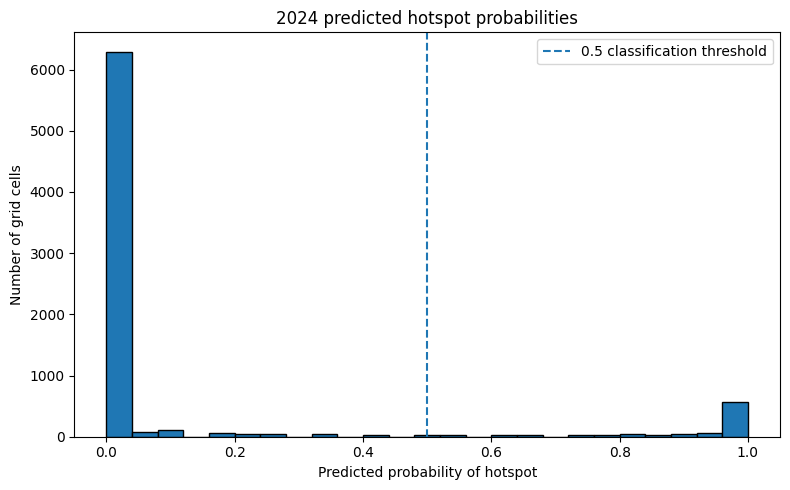

In [115]:
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_data[probability_column],
    bins=25,
    edgecolor="black"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="0.5 classification threshold"
)

plt.xlabel("Predicted probability of hotspot")
plt.ylabel("Number of grid cells")
plt.title("2024 predicted hotspot probabilities")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "predicted_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### My observation

In [116]:
probability_summary = analysis_data[
    probability_column
].describe()

display(probability_summary)

print(
    f"The median predicted probability was "
    f"{probability_summary['50%']:.3f}."
)

near_threshold = analysis_data[
    analysis_data[probability_column].between(
        0.40,
        0.60
    )
]

print(
    f"{len(near_threshold)} grid cells had probabilities "
    f"between 0.40 and 0.60."
)

print(
    "These are the cases where the model was relatively close "
    "to the classification boundary."
)

,predicted_probability_stage9
count,7.606000e+03
mean,1.193440e-01
std,2.987108e-01
min,5.647919e-10
25%,5.776701e-08
50%,5.908384e-06
75%,2.673673e-03
max,1.000000e+00


The median predicted probability was 0.000.
88 grid cells had probabilities between 0.40 and 0.60.
These are the cases where the model was relatively close to the classification boundary.


# First interpretation without SHAP

I am starting with the model's own coefficients or feature importance because this is easier to understand and check.

## 26. Logistic Regression coefficients and odds ratios, if selected

In [117]:
logistic_importance = pd.DataFrame()

if is_logistic_model and hasattr(fitted_estimator, "coef_"):
    coefficients = fitted_estimator.coef_.ravel()

    logistic_importance = pd.DataFrame({
        "feature": model_features,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
        "odds_ratio": np.exp(coefficients)
    }).sort_values(
        "absolute_coefficient",
        ascending=False
    )

    display(logistic_importance)
else:
    print(
        "Logistic Regression coefficients are not used "
        "because the selected model is not Logistic Regression."
    )

,feature,coefficient,absolute_coefficient,odds_ratio
0,log_previous_count,8.497987,8.497987,4904.885938
1,previous_hotspot,0.011214,0.011214,1.011277


### My Logistic Regression observation

In [118]:
if len(logistic_importance) > 0:
    for _, row in logistic_importance.iterrows():
        direction = (
            "increased"
            if row["coefficient"] > 0
            else "reduced"
        )

        print(
            f"{row['feature']} had a coefficient of "
            f"{row['coefficient']:.4f} and an odds ratio of "
            f"{row['odds_ratio']:.4f}. A higher model input "
            f"{direction} the predicted odds of hotspot status."
        )

    if use_separate_scaler or isinstance(selected_model, Pipeline):
        print(
            "Because scaling or preprocessing was used, the odds ratio "
            "is linked to the transformed model input rather than a raw "
            "one-unit change in the original variable."
        )

log_previous_count had a coefficient of 8.4980 and an odds ratio of 4904.8859. A higher model input increased the predicted odds of hotspot status.
previous_hotspot had a coefficient of 0.0112 and an odds ratio of 1.0113. A higher model input increased the predicted odds of hotspot status.
Because scaling or preprocessing was used, the odds ratio is linked to the transformed model input rather than a raw one-unit change in the original variable.


## 27. Tree-based feature importance, if selected

In [119]:
tree_importance = pd.DataFrame()

if is_tree_model and hasattr(
    fitted_estimator,
    "feature_importances_"
):
    tree_importance = pd.DataFrame({
        "feature": model_features,
        "feature_importance":
            fitted_estimator.feature_importances_
    }).sort_values(
        "feature_importance",
        ascending=False
    )

    display(tree_importance)
else:
    print(
        "Tree-based feature importance is not used "
        "because the selected model is not a supported tree model."
    )

Tree-based feature importance is not used because the selected model is not a supported tree model.


### My tree-model observation

In [120]:
if len(tree_importance) > 0:
    first_feature = tree_importance.iloc[0]

    print(
        f"The highest built-in feature importance was "
        f"{first_feature['feature']} with an importance of "
        f"{first_feature['feature_importance']:.4f}."
    )

    print(
        "This shows which feature the fitted tree model used more, "
        "but it does not show whether the feature increased or "
        "decreased hotspot probability."
    )

## 28. Permutation importance as a simple cross-check

In [121]:
if use_separate_scaler:
    permutation_model = fitted_estimator
    permutation_X = X_for_estimator
else:
    permutation_model = selected_model
    permutation_X = X_raw

permutation_results = permutation_importance(
    permutation_model,
    permutation_X,
    y_true,
    scoring="f1_macro",
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

permutation_importance_table = pd.DataFrame({
    "feature": model_features,
    "importance_mean":
        permutation_results.importances_mean,
    "importance_std":
        permutation_results.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

display(permutation_importance_table)

,feature,importance_mean,importance_std
0,log_previous_count,0.401578,0.003623
1,previous_hotspot,0.000000,0.000000


### My permutation-importance observation

In [122]:
top_permutation_feature = (
    permutation_importance_table.iloc[0]["feature"]
)

top_permutation_value = (
    permutation_importance_table.iloc[0]["importance_mean"]
)

print(
    f"After shuffling each feature, the largest average decrease "
    f"in macro F1 came from {top_permutation_feature} "
    f"({top_permutation_value:.4f})."
)

print(
    "This suggests that the model depended more on this feature "
    "for its held-out 2024 classifications."
)

After shuffling each feature, the largest average decrease in macro F1 came from log_previous_count (0.4016).
This suggests that the model depended more on this feature for its held-out 2024 classifications.


## 29. Plot the simplest available global importance

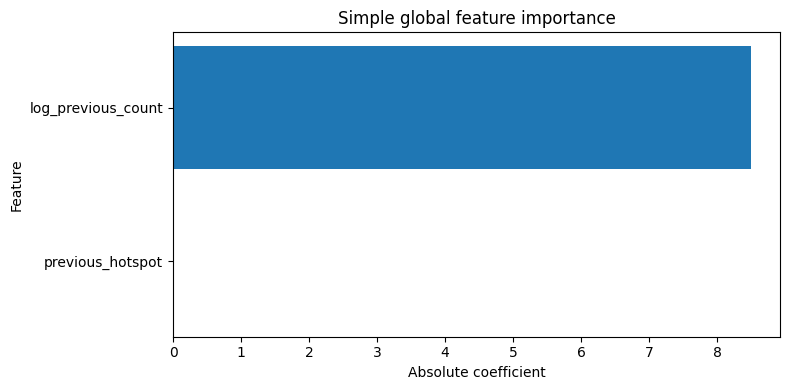

In [123]:
if len(logistic_importance) > 0:
    plot_data = logistic_importance.sort_values(
        "absolute_coefficient"
    )
    plot_values = plot_data["absolute_coefficient"]
    x_label = "Absolute coefficient"

elif len(tree_importance) > 0:
    plot_data = tree_importance.sort_values(
        "feature_importance"
    )
    plot_values = plot_data["feature_importance"]
    x_label = "Feature importance"

else:
    plot_data = permutation_importance_table.sort_values(
        "importance_mean"
    )
    plot_values = plot_data["importance_mean"]
    x_label = "Permutation importance"

plt.figure(figsize=(8, 4))

plt.barh(
    plot_data["feature"],
    plot_values
)

plt.xlabel(x_label)
plt.ylabel("Feature")
plt.title("Simple global feature importance")
plt.tight_layout()

plt.savefig(
    figures_path / "simple_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 30. Check the raw relationship between predictors and predicted probability

This is not a replacement for SHAP. It is a simple descriptive check before I use a more detailed explanation method.

In [124]:
if "log_previous_count" in analysis_data.columns:
    count_probability_correlation = analysis_data[
        "log_previous_count"
    ].corr(
        analysis_data[probability_column],
        method="spearman"
    )

    print(
        "Spearman correlation between log previous count "
        "and predicted probability:",
        round(count_probability_correlation, 4)
    )

Spearman correlation between log previous count and predicted probability: 1.0


In [125]:
if "previous_hotspot" in analysis_data.columns:
    previous_hotspot_probability = (
        analysis_data.groupby(
            "previous_hotspot"
        )[probability_column]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    display(previous_hotspot_probability)

,previous_hotspot,count,mean,median
0,0,6977,0.040959,8.656296e-07
1,1,629,0.988810,9.986638e-01


### My observation before SHAP

In [126]:
if "log_previous_count" in analysis_data.columns:
    if count_probability_correlation > 0.10:
        print(
            "Higher previous collision counts were generally linked "
            "with higher predicted hotspot probabilities."
        )
    elif count_probability_correlation < -0.10:
        print(
            "Higher previous collision counts were linked with lower "
            "predicted probabilities, which is not the expected direction."
        )
    else:
        print(
            "The relationship between previous collision count and "
            "predicted probability was weak."
        )

if (
    "previous_hotspot" in analysis_data.columns
    and set(previous_hotspot_probability["previous_hotspot"]) >= {0, 1}
):
    mean_not_previous = previous_hotspot_probability.loc[
        previous_hotspot_probability["previous_hotspot"] == 0,
        "mean"
    ].iloc[0]

    mean_previous = previous_hotspot_probability.loc[
        previous_hotspot_probability["previous_hotspot"] == 1,
        "mean"
    ].iloc[0]

    difference = mean_previous - mean_not_previous

    print(
        f"Previous hotspot grid cells had an average predicted "
        f"probability difference of {difference:.3f} compared with "
        f"non-hotspot grid cells."
    )

print(
    "These are model-based predictive associations, not causal findings."
)

Higher previous collision counts were generally linked with higher predicted hotspot probabilities.
Previous hotspot grid cells had an average predicted probability difference of 0.948 compared with non-hotspot grid cells.
These are model-based predictive associations, not causal findings.


# SHAP analysis

The simpler checks are now complete. I will install SHAP at this point rather than at the start of the notebook.

## 31. Install SHAP

In [127]:
%pip -q install shap

## 32. Import SHAP and check its version

In [128]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## 33. Use a smaller sample for SHAP

The full prediction dataset may be large, so I will use up to 1,000 rows. I use a fixed random state so that the same sample can be produced again.

In [129]:
shap_sample_size = min(1000, len(analysis_data))

shap_sample_positions = (
    analysis_data.sample(
        n=shap_sample_size,
        random_state=42
    ).index
)

X_shap_raw = X_raw.loc[
    shap_sample_positions
].copy()

X_shap_model = X_for_estimator.loc[
    shap_sample_positions
].copy()

shap_sample_data = analysis_data.loc[
    shap_sample_positions
].copy()

print("SHAP sample size:", len(X_shap_model))

SHAP sample size: 1000


## 34. Make a small background sample

I am using up to 200 rows as the SHAP reference data.

In [130]:
background_size = min(200, len(X_shap_model))

background_data = shap.sample(
    X_shap_model,
    background_size,
    random_state=42
)

print(background_data.shape)

(200, 2)


## 35. Try the model-specific SHAP explainer

I will use:

- `LinearExplainer` for Logistic Regression;
- `TreeExplainer` for Decision Tree, Random Forest or XGBoost.

If this produces a compatibility error, I will try the general `shap.Explainer`.

In [131]:
shap_worked = False
shap_method = None
shap_output = None
shap_explainer = None

try:
    if is_logistic_model:
        shap_explainer = shap.LinearExplainer(
            fitted_estimator,
            background_data
        )

        shap_output = shap_explainer(
            X_shap_model
        )

        shap_method = "LinearExplainer"

    elif is_tree_model:
        shap_explainer = shap.TreeExplainer(
            fitted_estimator
        )

        shap_output = shap_explainer(
            X_shap_model
        )

        shap_method = "TreeExplainer"

    else:
        raise ValueError(
            "The selected model is not recognised as linear or tree-based."
        )

    shap_worked = True

except Exception as first_error:
    print("The first SHAP method gave an error:")
    print(first_error)

    print("\nTrying the general SHAP explainer instead.")

    try:
        shap_explainer = shap.Explainer(
            fitted_estimator,
            background_data
        )

        shap_output = shap_explainer(
            X_shap_model
        )

        shap_method = "General SHAP Explainer"
        shap_worked = True

    except Exception as second_error:
        print("\nThe fallback SHAP method also gave an error:")
        print(second_error)

        print(
            "\nI will continue using coefficients, fitted feature "
            "importance and permutation importance."
        )

print("\nSHAP worked:", shap_worked)
print("SHAP method:", shap_method)


SHAP worked: True
SHAP method: LinearExplainer


## 36. Check the SHAP output structure

I am checking this before plotting because binary classification SHAP outputs can have different shapes.

In [132]:
if shap_worked:
    print("SHAP output type:", type(shap_output))

    if hasattr(shap_output, "values"):
        print(
            "SHAP values shape:",
            np.asarray(shap_output.values).shape
        )

        print(
            "Base values shape:",
            np.asarray(shap_output.base_values).shape
        )

SHAP output type: <class 'shap._explanation.Explanation'>
SHAP values shape: (1000, 2)
Base values shape: (1000,)


## 37. Convert SHAP output to a two-dimensional matrix

For a binary model, I want the contribution towards the positive hotspot class.

In [133]:
shap_values_matrix = None
shap_base_values = None

if shap_worked:
    shap_values_array = np.asarray(
        shap_output.values
    )

    shap_base_values = np.asarray(
        shap_output.base_values
    )

    if shap_values_array.ndim == 2:
        shap_values_matrix = shap_values_array

    elif shap_values_array.ndim == 3:
        if shap_values_array.shape[1] == X_shap_model.shape[1]:
            positive_class_position = (
                1 if shap_values_array.shape[2] > 1 else 0
            )

            shap_values_matrix = shap_values_array[
                :, :, positive_class_position
            ]

        elif shap_values_array.shape[2] == X_shap_model.shape[1]:
            positive_class_position = (
                1 if shap_values_array.shape[0] > 1 else 0
            )

            shap_values_matrix = shap_values_array[
                positive_class_position, :, :
            ]

    if shap_values_matrix is None:
        print("I could not convert the SHAP output automatically.")
        shap_worked = False

    else:
        print(
            "Final SHAP matrix shape:",
            shap_values_matrix.shape
        )

        print(
            "Feature data shape:",
            X_shap_model.shape
        )

Final SHAP matrix shape: (1000, 2)
Feature data shape: (1000, 2)


## 38. Create the SHAP global importance table

In [134]:
shap_global_importance = pd.DataFrame()

if shap_worked:
    shap_global_importance = pd.DataFrame({
        "feature": list(X_shap_model.columns),
        "mean_absolute_shap":
            np.abs(shap_values_matrix).mean(axis=0),
        "mean_shap":
            shap_values_matrix.mean(axis=0)
    }).sort_values(
        "mean_absolute_shap",
        ascending=False
    )

    display(shap_global_importance)
else:
    print("The SHAP importance table was not created.")

,feature,mean_absolute_shap,mean_shap
0,log_previous_count,6.655551,0.280187
1,previous_hotspot,0.005321,0.000745


### My SHAP importance observation

In [135]:
if len(shap_global_importance) > 0:
    first_shap_feature = shap_global_importance.iloc[0]
    second_shap_feature = (
        shap_global_importance.iloc[1]
        if len(shap_global_importance) > 1
        else None
    )

    print(
        f"The highest mean absolute SHAP value was for "
        f"{first_shap_feature['feature']} "
        f"({first_shap_feature['mean_absolute_shap']:.4f})."
    )

    if second_shap_feature is not None:
        ratio = (
            first_shap_feature["mean_absolute_shap"]
            / second_shap_feature["mean_absolute_shap"]
            if second_shap_feature["mean_absolute_shap"] != 0
            else np.inf
        )

        if ratio >= 2:
            print(
                "The first feature had at least twice the average "
                "SHAP influence of the second feature. The selected "
                "model appears to rely mainly on one predictor."
            )
        else:
            print(
                "The two features had more similar average SHAP "
                "influence, so both contributed to the predictions."
            )

The highest mean absolute SHAP value was for log_previous_count (6.6556).
The first feature had at least twice the average SHAP influence of the second feature. The selected model appears to rely mainly on one predictor.


## 39. SHAP summary bar plot

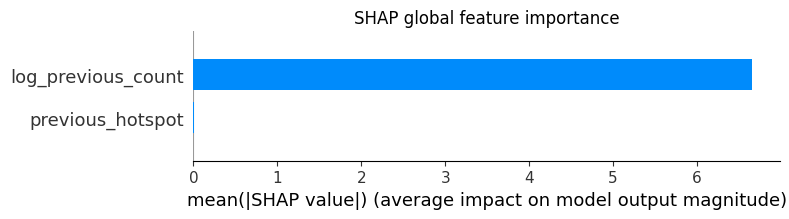

In [136]:
if shap_worked:
    shap.summary_plot(
        shap_values_matrix,
        X_shap_model,
        plot_type="bar",
        show=False
    )

    plt.title("SHAP global feature importance")
    plt.tight_layout()

    plt.savefig(
        figures_path / "shap_summary_bar.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 40. SHAP beeswarm plot

Points on the right push the model towards the hotspot class. Points on the left push the model away from the hotspot class.

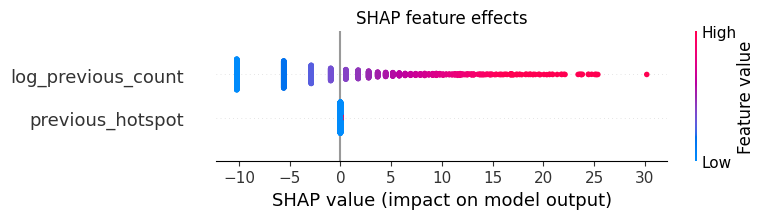

In [137]:
if shap_worked:
    shap.summary_plot(
        shap_values_matrix,
        X_shap_model,
        show=False
    )

    plt.title("SHAP feature effects")
    plt.tight_layout()

    plt.savefig(
        figures_path / "shap_beeswarm.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 41. Dependence plot for `log_previous_count`

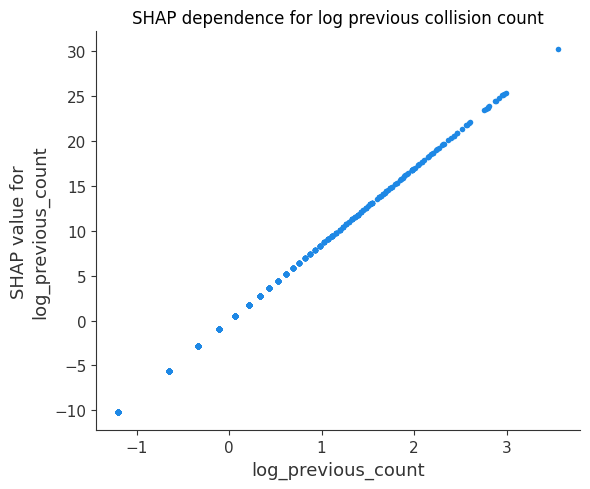

In [138]:
if (
    shap_worked
    and "log_previous_count" in X_shap_model.columns
):
    shap.dependence_plot(
        "log_previous_count",
        shap_values_matrix,
        X_shap_model,
        interaction_index=None,
        show=False
    )

    plt.title(
        "SHAP dependence for log previous collision count"
    )

    plt.tight_layout()

    plt.savefig(
        figures_path /
        "shap_dependence_log_previous_count.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 42. Dependence plot for `previous_hotspot`

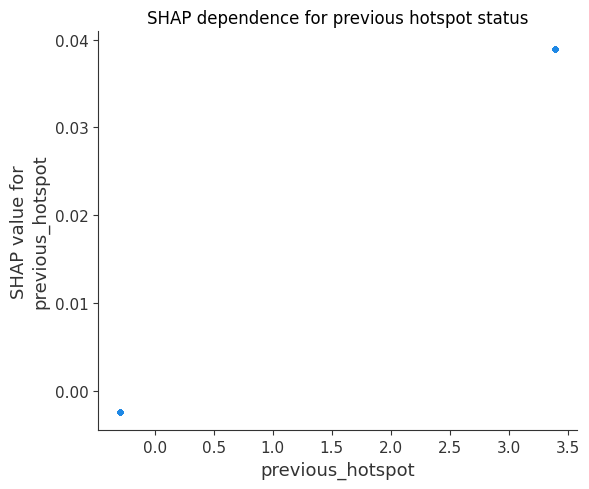

In [139]:
if (
    shap_worked
    and "previous_hotspot" in X_shap_model.columns
):
    shap.dependence_plot(
        "previous_hotspot",
        shap_values_matrix,
        X_shap_model,
        interaction_index=None,
        show=False
    )

    plt.title(
        "SHAP dependence for previous hotspot status"
    )

    plt.tight_layout()

    plt.savefig(
        figures_path /
        "shap_dependence_previous_hotspot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 43. Check SHAP direction more directly

In [140]:
shap_direction_table = pd.DataFrame()

if shap_worked:
    direction_rows = []

    for position, feature in enumerate(model_features):
        correlation_value = pd.Series(
            X_shap_model[feature].values
        ).corr(
            pd.Series(
                shap_values_matrix[:, position]
            ),
            method="spearman"
        )

        direction_rows.append({
            "feature": feature,
            "feature_shap_spearman":
                correlation_value,
            "mean_shap":
                shap_values_matrix[:, position].mean(),
            "mean_absolute_shap":
                np.abs(
                    shap_values_matrix[:, position]
                ).mean()
        })

    shap_direction_table = pd.DataFrame(
        direction_rows
    )

    display(shap_direction_table)

,feature,feature_shap_spearman,mean_shap,mean_absolute_shap
0,log_previous_count,1.0,0.280187,6.655551
1,previous_hotspot,1.0,0.000745,0.005321


### My SHAP direction observation

In [141]:
if len(shap_direction_table) > 0:
    if "log_previous_count" in shap_direction_table["feature"].values:
        count_shap_direction = shap_direction_table.loc[
            shap_direction_table["feature"]
            == "log_previous_count",
            "feature_shap_spearman"
        ].iloc[0]

        if count_shap_direction > 0.10:
            print(
                "Higher previous collision counts generally gave "
                "more positive SHAP contributions. This pushed the "
                "model towards future hotspot status."
            )
        elif count_shap_direction < -0.10:
            print(
                "Higher previous collision counts generally gave "
                "more negative SHAP contributions. This is an "
                "unexpected pattern that needs cautious discussion."
            )
        else:
            print(
                "The SHAP effect of previous collision count did not "
                "show a strong monotonic direction."
            )

    if "previous_hotspot" in X_shap_model.columns:
        previous_position = model_features.index(
            "previous_hotspot"
        )

        previous_status_shap = pd.DataFrame({
            "previous_hotspot":
                X_shap_raw["previous_hotspot"].values,
            "shap_value":
                shap_values_matrix[:, previous_position]
        })

        display(
            previous_status_shap.groupby(
                "previous_hotspot"
            )["shap_value"].agg(
                ["count", "mean", "median"]
            )
        )

    print(
        "SHAP explains the fitted model. It does not prove "
        "real-world causation."
    )

Higher previous collision counts generally gave more positive SHAP contributions. This pushed the model towards future hotspot status.


,count,mean,median
previous_hotspot,,,
0,922,-0.002482,-0.002482
1,78,0.038880,0.038880


SHAP explains the fitted model. It does not prove real-world causation.


# Looking at individual predictions

I now want to examine one example from each confusion category where it exists.

## 44. Select one true positive, true negative, false positive and false negative

In [142]:
selected_cases = {}

for case_type in [
    "True positive",
    "True negative",
    "False positive",
    "False negative"
]:
    case_rows = analysis_data[
        analysis_data["confusion_type"] == case_type
    ]

    if len(case_rows) == 0:
        selected_cases[case_type] = None

    elif case_type in [
        "True positive",
        "False positive"
    ]:
        selected_cases[case_type] = (
            case_rows[probability_column].idxmax()
        )

    else:
        selected_cases[case_type] = (
            case_rows[probability_column].idxmin()
        )

selected_cases

{'True positive': np.int64(1581),
 'True negative': np.int64(4),
 'False positive': np.int64(1734),
 'False negative': np.int64(4122)}

I selected high-probability positive predictions and low-probability negative predictions because these give clear examples of what the model was trying to do.

## 45. Display the selected raw cases

In [143]:
case_columns = [
    column
    for column in [
        "grid_id",
        "target_year",
        actual_column,
        predicted_column,
        probability_column,
        "confusion_type",
        "log_previous_count",
        "previous_hotspot"
    ]
    if column in analysis_data.columns
]

selected_case_rows = []

for case_type, row_index in selected_cases.items():
    if row_index is not None:
        selected_case_rows.append(
            analysis_data.loc[
                row_index,
                case_columns
            ]
        )

selected_case_table = pd.DataFrame(
    selected_case_rows
)

display(selected_case_table)

,grid_id,target_year,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,confusion_type,log_previous_count,previous_hotspot
1581,R034_C093,2024,1,1,1.000000e+00,True positive,7.251345,1
4,R001_C022,2024,0,0,5.647919e-10,True negative,0.000000,0
1734,R036_C103,2024,0,1,9.948005e-01,False positive,3.970292,1
4122,R067_C065,2024,1,0,8.479219e-02,False negative,2.833213,0


## 46. Add the selected cases to the SHAP sample if needed

The earlier random sample may not contain all four selected cases, so I calculate local SHAP values separately for these rows.

In [144]:
local_case_indexes = [
    row_index
    for row_index in selected_cases.values()
    if row_index is not None
]

X_local_raw = X_raw.loc[
    local_case_indexes
].copy()

X_local_model = X_for_estimator.loc[
    local_case_indexes
].copy()

print("Number of selected local cases:", len(X_local_model))

Number of selected local cases: 4


## 47. Calculate SHAP values for the local cases

In [145]:
local_shap_matrix = None
local_shap_output = None

if shap_worked:
    try:
        local_shap_output = shap_explainer(
            X_local_model
        )

        local_array = np.asarray(
            local_shap_output.values
        )

        if local_array.ndim == 2:
            local_shap_matrix = local_array

        elif local_array.ndim == 3:
            if local_array.shape[1] == len(model_features):
                positive_position = (
                    1 if local_array.shape[2] > 1 else 0
                )

                local_shap_matrix = local_array[
                    :, :, positive_position
                ]

            elif local_array.shape[2] == len(model_features):
                positive_position = (
                    1 if local_array.shape[0] > 1 else 0
                )

                local_shap_matrix = local_array[
                    positive_position, :, :
                ]

        print(
            "Local SHAP matrix shape:",
            None if local_shap_matrix is None
            else local_shap_matrix.shape
        )

    except Exception as local_error:
        print("Local SHAP calculation gave an error:")
        print(local_error)

Local SHAP matrix shape: (4, 2)


## 48. Create a table connecting raw values to local SHAP contributions

In [146]:
local_explanation_rows = []

if local_shap_matrix is not None:
    for local_position, row_index in enumerate(
        local_case_indexes
    ):
        case_type = analysis_data.loc[
            row_index,
            "confusion_type"
        ]

        for feature_position, feature in enumerate(
            X_local_model.columns
        ):
            local_explanation_rows.append({
                "case_type": case_type,
                "grid_id": (
                    analysis_data.loc[row_index, "grid_id"]
                    if "grid_id" in analysis_data.columns
                    else row_index
                ),
                "feature": feature,
                "raw_feature_value": (
                    X_local_raw.loc[row_index, feature]
                    if feature in X_local_raw.columns
                    else np.nan
                ),
                "model_feature_value":
                    X_local_model.loc[row_index, feature],
                "shap_contribution":
                    local_shap_matrix[
                        local_position,
                        feature_position
                    ],
                "actual_class":
                    analysis_data.loc[
                        row_index,
                        actual_column
                    ],
                "predicted_class":
                    analysis_data.loc[
                        row_index,
                        predicted_column
                    ],
                "predicted_probability":
                    analysis_data.loc[
                        row_index,
                        probability_column
                    ]
            })

local_explanations = pd.DataFrame(
    local_explanation_rows
)

display(local_explanations)

,case_type,grid_id,feature,raw_feature_value,model_feature_value,shap_contribution,actual_class,predicted_class,predicted_probability
0,True positive,R034_C093,log_previous_count,7.251345,4.500372,38.200783,1,1,1.000000e+00
1,True positive,R034_C093,previous_hotspot,1.000000,3.393631,0.038880,1,1,1.000000e+00
2,True negative,R001_C022,log_previous_count,0.000000,-1.196595,-10.211970,0,0,5.647919e-10
3,True negative,R001_C022,previous_hotspot,0.000000,-0.294670,-0.002482,0,0,5.647919e-10
4,False positive,R036_C103,log_previous_count,3.970292,1.922636,16.295217,0,1,9.948005e-01
5,False positive,R036_C103,previous_hotspot,1.000000,3.393631,0.038880,0,1,9.948005e-01
6,False negative,R067_C065,log_previous_count,2.833213,1.029299,8.703646,1,0,8.479219e-02
7,False negative,R067_C065,previous_hotspot,0.000000,-0.294670,-0.002482,1,0,8.479219e-02


## 49. Create waterfall plots for the selected cases

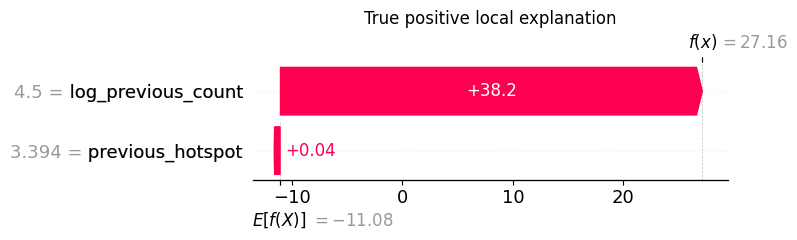

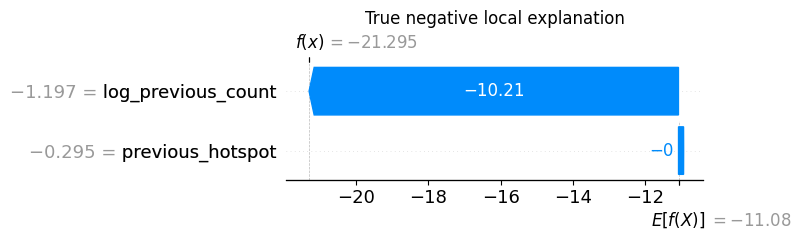

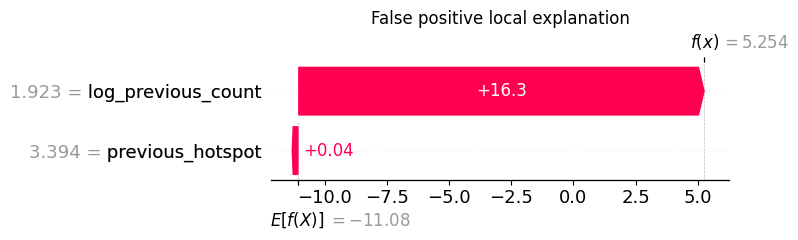

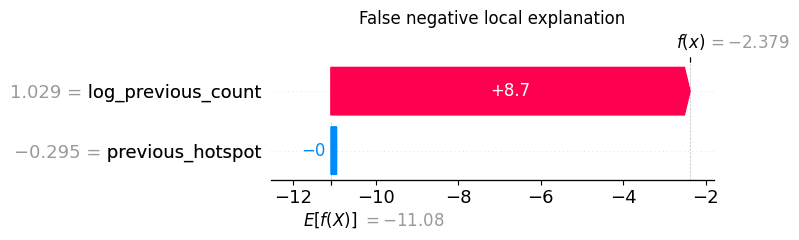

In [147]:
if local_shap_matrix is not None:
    local_base_values = np.asarray(
        local_shap_output.base_values
    )

    for local_position, row_index in enumerate(
        local_case_indexes
    ):
        case_type = analysis_data.loc[
            row_index,
            "confusion_type"
        ]

        if local_base_values.ndim == 0:
            base_value = float(local_base_values)

        elif local_base_values.ndim == 1:
            if len(local_base_values) == len(
                local_case_indexes
            ):
                base_value = float(
                    local_base_values[local_position]
                )
            elif len(local_base_values) > 1:
                base_value = float(local_base_values[1])
            else:
                base_value = float(local_base_values[0])

        else:
            positive_position = (
                1 if local_base_values.shape[1] > 1 else 0
            )

            base_value = float(
                local_base_values[
                    local_position,
                    positive_position
                ]
            )

        explanation_for_plot = shap.Explanation(
            values=local_shap_matrix[local_position],
            base_values=base_value,
            data=X_local_model.loc[
                row_index
            ].values,
            feature_names=list(X_local_model.columns)
        )

        shap.plots.waterfall(
            explanation_for_plot,
            max_display=len(X_local_model.columns),
            show=False
        )

        plt.title(
            f"{case_type} local explanation"
        )

        plt.tight_layout()

        file_name = (
            case_type.lower().replace(" ", "_")
            + "_waterfall.png"
        )

        plt.savefig(
            figures_path / file_name,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

## 50. Write observations for the selected local cases

In [148]:
local_observations = []

if len(local_explanations) > 0:
    for case_type in [
        "True positive",
        "True negative",
        "False positive",
        "False negative"
    ]:
        case_values = local_explanations[
            local_explanations["case_type"]
            == case_type
        ]

        if len(case_values) == 0:
            local_observations.append(
                f"No {case_type.lower()} was available."
            )
            continue

        probability_value = case_values[
            "predicted_probability"
        ].iloc[0]

        strongest_positive = case_values.sort_values(
            "shap_contribution",
            ascending=False
        ).iloc[0]

        strongest_negative = case_values.sort_values(
            "shap_contribution",
            ascending=True
        ).iloc[0]

        if case_type == "True positive":
            message = (
                f"The selected true positive had a probability of "
                f"{probability_value:.3f}. The strongest contribution "
                f"towards hotspot status came from "
                f"{strongest_positive['feature']}."
            )

        elif case_type == "True negative":
            message = (
                f"The selected true negative had a probability of "
                f"{probability_value:.3f}. The strongest contribution "
                f"away from hotspot status came from "
                f"{strongest_negative['feature']}."
            )

        elif case_type == "False positive":
            message = (
                f"The selected false positive had a probability of "
                f"{probability_value:.3f}. The model was mainly pushed "
                f"towards hotspot status by "
                f"{strongest_positive['feature']}, but the grid cell "
                f"did not become a 2024 hotspot."
            )

        else:
            message = (
                f"The selected false negative had a probability of "
                f"{probability_value:.3f}. The strongest contribution "
                f"away from hotspot status came from "
                f"{strongest_negative['feature']}. The previous-year "
                f"information was not enough for the model to identify "
                f"this actual 2024 hotspot."
            )

        local_observations.append(message)

for message in local_observations:
    print("-", message)

- The selected true positive had a probability of 1.000. The strongest contribution towards hotspot status came from log_previous_count.
- The selected true negative had a probability of 0.000. The strongest contribution away from hotspot status came from log_previous_count.
- The selected false positive had a probability of 0.995. The model was mainly pushed towards hotspot status by log_previous_count, but the grid cell did not become a 2024 hotspot.
- The selected false negative had a probability of 0.085. The strongest contribution away from hotspot status came from previous_hotspot. The previous-year information was not enough for the model to identify this actual 2024 hotspot.


# Looking more closely at high-risk and incorrect predictions

## 51. Highest predicted hotspot probabilities

In [149]:
high_probability_columns = [
    column
    for column in [
        "grid_id",
        "target_year",
        "log_previous_count",
        "previous_hotspot",
        actual_column,
        predicted_column,
        probability_column,
        "confusion_type"
    ]
    if column in analysis_data.columns
]

highest_probabilities = (
    analysis_data[high_probability_columns]
    .sort_values(
        probability_column,
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(highest_probabilities)

,grid_id,target_year,log_previous_count,previous_hotspot,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,confusion_type
0,R034_C093,2024,7.251345,1,1,1,1.0,True positive
1,R034_C092,2024,7.153834,1,1,1,1.0,True positive
2,R033_C093,2024,7.135687,1,1,1,1.0,True positive
3,R033_C092,2024,7.034388,1,1,1,1.0,True positive
4,R035_C093,2024,6.954639,1,1,1,1.0,True positive
5,R034_C094,2024,6.775366,1,1,1,1.0,True positive
6,R034_C091,2024,6.650279,1,1,1,1.0,True positive
7,R031_C093,2024,6.639876,1,1,1,1.0,True positive
8,R032_C092,2024,6.620073,1,1,1,1.0,True positive
9,R036_C093,2024,6.551080,1,1,1,1.0,True positive


## 52. Check whether high probabilities are connected to one feature or both

I define a high previous count as being at or above the 75th percentile. This is only a simple descriptive grouping.

In [150]:
top_probability_cutoff = analysis_data[
    probability_column
].quantile(0.90)

top_probability_group = analysis_data[
    analysis_data[probability_column]
    >= top_probability_cutoff
].copy()

if "log_previous_count" in top_probability_group.columns:
    high_count_cutoff = analysis_data[
        "log_previous_count"
    ].quantile(0.75)

    top_probability_group["high_previous_count"] = (
        top_probability_group["log_previous_count"]
        >= high_count_cutoff
    )
else:
    top_probability_group["high_previous_count"] = False

if "previous_hotspot" in top_probability_group.columns:
    top_probability_group["was_previous_hotspot"] = (
        top_probability_group["previous_hotspot"] == 1
    )
else:
    top_probability_group["was_previous_hotspot"] = False

top_probability_group["signal_pattern"] = "Neither"

top_probability_group.loc[
    top_probability_group["high_previous_count"]
    & top_probability_group["was_previous_hotspot"],
    "signal_pattern"
] = "High count and previous hotspot"

top_probability_group.loc[
    top_probability_group["high_previous_count"]
    & ~top_probability_group["was_previous_hotspot"],
    "signal_pattern"
] = "High count only"

top_probability_group.loc[
    ~top_probability_group["high_previous_count"]
    & top_probability_group["was_previous_hotspot"],
    "signal_pattern"
] = "Previous hotspot only"

top_signal_summary = (
    top_probability_group["signal_pattern"]
    .value_counts()
    .rename_axis("signal_pattern")
    .reset_index(name="count")
)

top_signal_summary["percentage"] = (
    top_signal_summary["count"]
    / top_signal_summary["count"].sum()
    * 100
)

display(top_signal_summary)

,signal_pattern,count,percentage
0,High count and previous hotspot,629,81.901042
1,High count only,139,18.098958


### My high-probability observation

In [151]:
main_pattern = top_signal_summary.iloc[0]

print(
    f"The most common pattern in the top 10% of predicted "
    f"probabilities was '{main_pattern['signal_pattern']}', "
    f"covering {main_pattern['percentage']:.1f}% of these cases."
)

print(
    "This helps show whether the model's highest-risk predictions "
    "were mainly connected to previous collision count, previous "
    "hotspot status or both."
)

The most common pattern in the top 10% of predicted probabilities was 'High count and previous hotspot', covering 81.9% of these cases.
This helps show whether the model's highest-risk predictions were mainly connected to previous collision count, previous hotspot status or both.


## 53. Create a table of all incorrect predictions

In [152]:
incorrect_predictions = analysis_data[
    ~analysis_data["correct_prediction"]
].copy()

incorrect_prediction_table = (
    incorrect_predictions[
        [
            column
            for column in high_probability_columns
            if column in incorrect_predictions.columns
        ]
    ]
    .sort_values(
        ["confusion_type", probability_column]
    )
    .reset_index(drop=True)
)

print("Incorrect predictions:", len(incorrect_prediction_table))
display(incorrect_prediction_table.head(20))

Incorrect predictions: 271


,grid_id,target_year,log_previous_count,previous_hotspot,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,confusion_type
0,R067_C065,2024,2.833213,0,1,0,0.084792,False negative
1,R035_C052,2024,2.944439,0,1,0,0.162961,False negative
2,R020_C080,2024,3.091042,0,1,0,0.341283,False negative
3,R030_C061,2024,3.135494,0,1,0,0.410765,False negative
4,R035_C105,2024,3.135494,0,1,0,0.410765,False negative
5,R060_C066,2024,3.135494,0,1,0,0.410765,False negative
6,R062_C065,2024,3.178054,0,1,0,0.480844,False negative
7,R016_C071,2024,3.218876,0,0,1,0.548815,False positive
8,R018_C069,2024,3.218876,0,0,1,0.548815,False positive
9,R019_C082,2024,3.218876,0,0,1,0.548815,False positive


## 54. Compare correct and incorrect predictions

In [153]:
analysis_data["distance_from_0_5"] = np.abs(
    analysis_data[probability_column] - 0.5
)

comparison_columns = [
    probability_column,
    "distance_from_0_5"
] + model_features

correct_incorrect_summary = (
    analysis_data.groupby(
        "correct_prediction"
    )[comparison_columns]
    .agg(["count", "mean", "median"])
)

display(correct_incorrect_summary)

predicted_probability_stage9                      \
                                          count      mean    median   
correct_prediction                                                    
False                                       271  0.773859  0.804259   
True                                       7335  0.095162  0.000006   

                   distance_from_0_5                     log_previous_count  \
                               count      mean    median              count   
correct_prediction                                                            
False                            271  0.282699  0.304259                271   
True                            7335  0.485568  0.499994               7335   

                                       previous_hotspot                   
                        mean    median            count      mean median  
correct_prediction                                                        
False               3.425244  3.401197              271  0.239852    0.0  
True                1.498594  1.386294             7335  0.076892    0.0

### My correct-versus-incorrect observation

In [154]:
correct_median_distance = analysis_data.loc[
    analysis_data["correct_prediction"],
    "distance_from_0_5"
].median()

incorrect_median_distance = analysis_data.loc[
    ~analysis_data["correct_prediction"],
    "distance_from_0_5"
].median()

print(
    f"Correct predictions had a median distance of "
    f"{correct_median_distance:.3f} from the 0.5 boundary."
)

print(
    f"Incorrect predictions had a median distance of "
    f"{incorrect_median_distance:.3f} from the 0.5 boundary."
)

if incorrect_median_distance < correct_median_distance:
    print(
        "The incorrect predictions were closer to 0.5 on average, "
        "so they were more uncertain."
    )
else:
    print(
        "The incorrect predictions were not closer to 0.5 on average. "
        "This means that some errors were made with fairly confident "
        "probabilities."
    )

Correct predictions had a median distance of 0.500 from the 0.5 boundary.
Incorrect predictions had a median distance of 0.304 from the 0.5 boundary.
The incorrect predictions were closer to 0.5 on average, so they were more uncertain.


## 55. Compare false positives and false negatives

In [155]:
error_summary = (
    analysis_data[
        analysis_data["confusion_type"].isin(
            ["False positive", "False negative"]
        )
    ]
    .groupby("confusion_type")[
        model_features
        + [probability_column, "distance_from_0_5"]
    ]
    .agg(["count", "mean", "median"])
)

display(error_summary)

log_previous_count                     previous_hotspot  \
                            count      mean    median            count   
confusion_type                                                           
False negative                  7  3.064747  3.135494                7   
False positive                264  3.434803  3.401197              264   

                                predicted_probability_stage9            \
                    mean median                        count      mean   
confusion_type                                                           
False negative  0.000000    0.0                            7  0.328882   
False positive  0.246212    0.0                          264  0.785657   

                         distance_from_0_5                      
                  median             count      mean    median  
confusion_type                                                  
False negative  0.410765                 7  0.171118  0.089235  
False positive  0.804259               264  0.285657  0.304259

### My error interpretation

In [156]:
false_positive_count = (
    analysis_data["confusion_type"]
    == "False positive"
).sum()

false_negative_count = (
    analysis_data["confusion_type"]
    == "False negative"
).sum()

print("False positives:", false_positive_count)
print("False negatives:", false_negative_count)

if false_positive_count > 0:
    false_positive_probability = analysis_data.loc[
        analysis_data["confusion_type"]
        == "False positive",
        probability_column
    ].mean()

    print(
        f"False positives had a mean predicted probability of "
        f"{false_positive_probability:.3f}."
    )

    print(
        "A possible reason is that these grid cells had strong "
        "previous-year hotspot signals but did not cross the "
        "year-specific 2024 hotspot threshold."
    )

if false_negative_count > 0:
    false_negative_probability = analysis_data.loc[
        analysis_data["confusion_type"]
        == "False negative",
        probability_column
    ].mean()

    print(
        f"False negatives had a mean predicted probability of "
        f"{false_negative_probability:.3f}."
    )

    print(
        "A possible reason is that some 2024 hotspots were emerging "
        "or changing and were not well represented by the previous "
        "year's collision count and hotspot status."
    )

print(
    "Other road, traffic, weather and local variables were not "
    "included in this two-feature predictive model."
)

False positives: 264
False negatives: 7
False positives had a mean predicted probability of 0.786.
A possible reason is that these grid cells had strong previous-year hotspot signals but did not cross the year-specific 2024 hotspot threshold.
False negatives had a mean predicted probability of 0.329.
A possible reason is that some 2024 hotspots were emerging or changing and were not well represented by the previous year's collision count and hotspot status.
Other road, traffic, weather and local variables were not included in this two-feature predictive model.


# Checking consistency with Stage 7

I will look for Stage 7 coefficient tables. I will only make a direct comparison if the relevant files can be found automatically.

## 56. Look for possible Stage 7 statistical result files

In [157]:
stage7_csv_files = list(
    stage7_path.rglob("*.csv")
)

possible_stage7_result_files = [
    file_path
    for file_path in stage7_csv_files
    if any(
        text in file_path.name.lower()
        for text in [
            "logistic",
            "coefficient",
            "gee",
            "odds",
            "model_result"
        ]
    )
]

for file_path in possible_stage7_result_files:
    print(file_path.name)

logistic_regression_results.csv
previous_hotspot_logistic_results.csv
logistic_gee_comparison.csv


## 57. Try to read predictor directions from Stage 7

In [158]:
stage7_direction_results = []

for file_path in possible_stage7_result_files:
    try:
        table = pd.read_csv(file_path)
    except Exception:
        continue

    term_column = None
    estimate_column = None

    for name in [
        "term",
        "feature",
        "predictor",
        "variable"
    ]:
        if name in table.columns:
            term_column = name
            break

    for name in [
        "coefficient",
        "estimate",
        "coef",
        "beta",
        "odds_ratio"
    ]:
        if name in table.columns:
            estimate_column = name
            break

    if (
        term_column is None
        or estimate_column is None
    ):
        continue

    for feature in [
        "log_previous_count",
        "previous_hotspot"
    ]:
        matching_rows = table[
            table[term_column]
            .astype(str)
            .str.contains(
                feature,
                case=False,
                na=False
            )
        ]

        if len(matching_rows) > 0:
            stage7_direction_results.append({
                "file": file_path.name,
                "feature": feature,
                "estimate_column":
                    estimate_column,
                "stage7_value":
                    pd.to_numeric(
                        matching_rows.iloc[0][
                            estimate_column
                        ],
                        errors="coerce"
                    )
            })

stage7_direction_table = pd.DataFrame(
    stage7_direction_results
)

display(stage7_direction_table)

,file,feature,estimate_column,stage7_value
0,logistic_regression_results.csv,log_previous_count,coefficient,7.101123
1,previous_hotspot_logistic_results.csv,previous_hotspot,coefficient,6.822076


### My Stage 7 comparison observation

In [159]:
stage7_consistency_note = (
    "A direct automatic comparison with Stage 7 was not possible "
    "because a suitable coefficient table was not found."
)

if len(stage7_direction_table) > 0:
    stage7_consistency_note = (
        "A Stage 7 coefficient table was found. The predictor "
        "directions can now be compared with the Stage 9 model "
        "and SHAP directions shown above."
    )

print(stage7_consistency_note)

A Stage 7 coefficient table was found. The predictor directions can now be compared with the Stage 9 model and SHAP directions shown above.


# Save the Stage 9 outputs

I am saving the main tables and figures now so that they can be checked later and used in the next stages.

## 58. Save the global importance tables

In [160]:
if len(logistic_importance) > 0:
    logistic_importance.to_csv(
        tables_path /
        "logistic_coefficients_and_odds_ratios.csv",
        index=False
    )

if len(tree_importance) > 0:
    tree_importance.to_csv(
        tables_path /
        "tree_feature_importance.csv",
        index=False
    )

permutation_importance_table.to_csv(
    tables_path /
    "permutation_importance.csv",
    index=False
)

if len(shap_global_importance) > 0:
    shap_global_importance.to_csv(
        tables_path /
        "shap_global_importance.csv",
        index=False
    )

print("Global importance tables saved.")

Global importance tables saved.


## 59. Save the local explanation and error tables

In [161]:
selected_case_table.to_csv(
    tables_path /
    "selected_individual_cases.csv",
    index=False
)

if len(local_explanations) > 0:
    local_explanations.to_csv(
        tables_path /
        "selected_local_shap_explanations.csv",
        index=False
    )

highest_probabilities.to_csv(
    tables_path /
    "highest_predicted_probabilities_2024.csv",
    index=False
)

incorrect_prediction_table.to_csv(
    tables_path /
    "incorrect_predictions_2024.csv",
    index=False
)

top_signal_summary.to_csv(
    tables_path /
    "high_probability_signal_summary.csv",
    index=False
)

print("Local and error tables saved.")

Local and error tables saved.


## 60. Save a manageable SHAP sample

In [162]:
if shap_worked:
    shap_sample_output = shap_sample_data[
        [
            column
            for column in [
                "grid_id",
                "target_year",
                actual_column,
                predicted_column,
                probability_column,
                "confusion_type"
            ] + model_features
            if column in shap_sample_data.columns
        ]
    ].reset_index(drop=True)

    for position, feature in enumerate(
        model_features
    ):
        shap_sample_output[
            f"shap_{feature}"
        ] = shap_values_matrix[:, position]

    shap_sample_output.to_csv(
        tables_path /
        "shap_values_sample.csv",
        index=False
    )

    display(shap_sample_output.head())

,grid_id,target_year,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,confusion_type,log_previous_count,previous_hotspot,shap_log_previous_count,shap_previous_hotspot
0,R047_C105,2024,0,0,5.908384e-06,True negative,1.386294,0,-0.956539,-0.002482
1,R042_C107,2024,1,1,9.971451e-01,True positive,4.060443,1,16.897100,0.038880
2,R124_C036,2024,0,0,5.908384e-06,True negative,1.386294,0,-0.956539,-0.002482
3,R010_C030,2024,0,0,5.039994e-03,True negative,2.397895,0,5.797296,-0.002482
4,R054_C085,2024,0,0,5.776701e-08,True negative,0.693147,0,-5.584254,-0.002482


## 61. Create a dashboard-ready Stage 9 table

This file contains the values that may later be useful in Power BI. I am only preparing the file here and not building the dashboard yet.

In [163]:
dashboard_columns = [
    column
    for column in [
        "grid_id",
        "target_year",
        "log_previous_count",
        "previous_hotspot",
        actual_column,
        predicted_column,
        probability_column,
        "correct_prediction",
        "confusion_type",
        "distance_from_0_5"
    ]
    if column in analysis_data.columns
]

dashboard_stage9_table = analysis_data[
    dashboard_columns
].copy()

dashboard_stage9_table.to_csv(
    tables_path /
    "stage9_dashboard_explainability_2024.csv",
    index=False
)

print("Dashboard-ready rows:", len(dashboard_stage9_table))
dashboard_stage9_table.head()

Dashboard-ready rows: 7606


,grid_id,target_year,log_previous_count,previous_hotspot,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,correct_prediction,confusion_type,distance_from_0_5
0,R000_C005,2024,1.386294,0,0,0,5.908384e-06,True,True negative,0.499994
1,R000_C021,2024,1.098612,0,0,0,8.656296e-07,True,True negative,0.499999
2,R001_C020,2024,1.609438,0,0,0,2.621007e-05,True,True negative,0.499974
3,R001_C021,2024,0.693147,0,0,0,5.776701e-08,True,True negative,0.500000
4,R001_C022,2024,0.000000,0,0,0,5.647919e-10,True,True negative,0.500000


## 62. Create the completed Stage 9 summary from the actual results

In [164]:
summary_text = []

summary_text.append(
    "STAGE 9: EXPLAINABLE AI AND INTERPRETATION"
)
summary_text.append("=" * 50)
summary_text.append("")

summary_text.append(
    f"Selected model interpreted: "
    f"{selected_model_name or estimator_name}"
)

summary_text.append(
    f"Loaded estimator class: {estimator_name}"
)

summary_text.append(
    f"SHAP method used: "
    f"{shap_method if shap_worked else 'SHAP was not available'}"
)

summary_text.append("")

summary_text.append("2024 performance check:")

for metric, value in metric_results.items():
    summary_text.append(
        f"- {metric}: {value:.4f}"
    )

summary_text.append("")

if len(shap_global_importance) > 0:
    summary_text.append(
        "Most influential predictors by mean absolute SHAP:"
    )

    for _, row in shap_global_importance.iterrows():
        summary_text.append(
            f"- {row['feature']}: "
            f"{row['mean_absolute_shap']:.4f}"
        )

elif len(logistic_importance) > 0:
    summary_text.append(
        "Predictors were interpreted using Logistic Regression "
        "coefficients and odds ratios."
    )

elif len(tree_importance) > 0:
    summary_text.append(
        "Predictors were interpreted using fitted tree-based "
        "feature importance."
    )

summary_text.append("")

summary_text.append("Local prediction observations:")

for message in local_observations:
    summary_text.append(f"- {message}")

summary_text.append("")

summary_text.append("Error findings:")
summary_text.append(
    f"- False positives: {false_positive_count}"
)
summary_text.append(
    f"- False negatives: {false_negative_count}"
)

summary_text.append(
    f"- Correct prediction median distance from 0.5: "
    f"{correct_median_distance:.3f}"
)

summary_text.append(
    f"- Incorrect prediction median distance from 0.5: "
    f"{incorrect_median_distance:.3f}"
)

summary_text.append("")

summary_text.append("Stage 7 comparison:")
summary_text.append(
    f"- {stage7_consistency_note}"
)

summary_text.append("")

summary_text.append("Main interpretation:")
summary_text.append(
    "- The selected model used previous-year collision information "
    "to estimate future hotspot probability."
)
summary_text.append(
    "- Positive coefficients or SHAP values pushed predictions "
    "towards hotspot status."
)
summary_text.append(
    "- Negative contributions pushed predictions away from "
    "hotspot status."
)
summary_text.append(
    "- False positives may reflect strong previous risk signals "
    "that did not continue into the target year."
)
summary_text.append(
    "- False negatives may reflect emerging or changing hotspot "
    "patterns not captured by the two predictors."
)

summary_text.append("")

summary_text.append("Important limitations:")
summary_text.append(
    "- SHAP explains model behaviour, not real-world causation."
)
summary_text.append(
    "- Feature importance does not prove that a predictor causes "
    "future collisions."
)
summary_text.append(
    "- Only two previous-year predictors were used."
)
summary_text.append(
    "- Other road, weather, traffic and local variables were "
    "not included."
)
summary_text.append(
    "- The hotspot target is based on a yearly 90th percentile "
    "threshold."
)

summary_text.append("")

summary_text.append("Files to carry forward to Stage 10:")
summary_text.append(
    f"- Selected model: {model_file}"
)
summary_text.append(
    f"- Stage 8 prediction file: {prediction_file}"
)
summary_text.append(
    f"- Dashboard-ready Stage 9 table: "
    f"{tables_path / 'stage9_dashboard_explainability_2024.csv'}"
)
summary_text.append(
    f"- Highest predicted probabilities: "
    f"{tables_path / 'highest_predicted_probabilities_2024.csv'}"
)
summary_text.append(
    f"- Incorrect predictions: "
    f"{tables_path / 'incorrect_predictions_2024.csv'}"
)
summary_text.append(
    f"- Figures folder: {figures_path}"
)

completed_summary = "\n".join(
    summary_text
)

print(completed_summary)

STAGE 9: EXPLAINABLE AI AND INTERPRETATION

Selected model interpreted: Logistic Regression balanced train
Loaded estimator class: LogisticRegression
SHAP method used: LinearExplainer

2024 performance check:
- accuracy: 0.9644
- precision_hotspot: 0.7020
- recall_hotspot: 0.9889
- hotspot_f1: 0.8211
- macro_f1: 0.9007
- roc_auc: 0.9971

Most influential predictors by mean absolute SHAP:
- log_previous_count: 6.6556
- previous_hotspot: 0.0053

Local prediction observations:
- The selected true positive had a probability of 1.000. The strongest contribution towards hotspot status came from log_previous_count.
- The selected true negative had a probability of 0.000. The strongest contribution away from hotspot status came from log_previous_count.
- The selected false positive had a probability of 0.995. The model was mainly pushed towards hotspot status by log_previous_count, but the grid cell did not become a 2024 hotspot.
- The selected false negative had a probability of 0.085. The st

## 63. Save the written summary

In [165]:
summary_file = (
    notes_path /
    "stage9_completed_interpretation_summary.txt"
)

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as file:
    file.write(completed_summary)

print("Saved summary:")
print(summary_file)

Saved summary:
/content/drive/MyDrive/disseration/stage9_outputs/notes/stage9_completed_interpretation_summary.txt


## 64. Final check of the files created in Stage 9

In [166]:
stage9_files = [
    path
    for path in stage9_path.rglob("*")
    if path.is_file()
]

output_check = pd.DataFrame({
    "file_name": [
        path.name
        for path in stage9_files
    ],
    "folder": [
        str(path.parent)
        for path in stage9_files
    ],
    "size_kb": [
        round(path.stat().st_size / 1024, 2)
        for path in stage9_files
    ]
}).sort_values(
    ["folder", "file_name"]
)

display(output_check)

,file_name,folder,size_kb
19,false_negative_waterfall.png,/content/drive/MyDrive/disseration/stage9_outp...,81.51
18,false_positive_waterfall.png,/content/drive/MyDrive/disseration/stage9_outp...,86.06
10,predicted_probability_distribution.png,/content/drive/MyDrive/disseration/stage9_outp...,97.49
14,shap_beeswarm.png,/content/drive/MyDrive/disseration/stage9_outp...,94.98
13,shap_dependence_log_previous_count.png,/content/drive/MyDrive/disseration/stage9_outp...,97.02
15,shap_dependence_previous_hotspot.png,/content/drive/MyDrive/disseration/stage9_outp...,88.92
12,shap_summary_bar.png,/content/drive/MyDrive/disseration/stage9_outp...,77.74
11,simple_global_feature_importance.png,/content/drive/MyDrive/disseration/stage9_outp...,65.88
17,true_negative_waterfall.png,/content/drive/MyDrive/disseration/stage9_outp...,78.67
16,true_positive_waterfall.png,/content/drive/MyDrive/disseration/stage9_outp...,78.33


# Final Stage 9 note

I have now interpreted the model that was selected in Stage 8.

The main Stage 9 work included:

- checking which model was selected;
- loading the saved fitted model without retraining it;
- checking the original Stage 8 predictors;
- reviewing actual and predicted 2024 classes;
- checking probability uncertainty;
- interpreting coefficients or tree-based importance;
- calculating permutation importance;
- using SHAP where it was compatible;
- examining true positives, true negatives, false positives and false negatives;
- saving explanation tables and figures.

These explanations show how the fitted model used the available previous-year variables. They should not be described as proof that previous collision count or previous hotspot status causes future hotspot formation.

I will use the saved Stage 9 tables and figures in the later Power BI and dissertation evaluation stages, but I am not starting those stages in this notebook.

 Adding Place Names Before Power BI


# Stage 9 Continuation - Add Place Names to the Hotspot Grids

**Dissertation:** *Spatio-Temporal Analysis and Visualisation of Persistent Road Traffic Collision Hotspots in Great Britain*

I have completed Stage 9. Before starting the Power BI dashboard, I want the hotspot grids to have readable place names.

While checking my earlier notebooks, I realised that I do **not** have objects called `collision_grid` or `hotspot_summary`. I therefore decided not to depend on old notebook variables.

Instead, I am going back to the saved spatial hotspot output from Stage 6:

`stage6_outputs/grid_persistence_5km.gpkg`

This is actually more suitable because it already contains:

- one record per 5 km grid
- `grid_id`
- the grid geometry
- hotspot persistence results
- persistence and temporal-pattern fields

I will match these grid polygons with the OS Open Built Up Areas polygons and assign the settlement with the **largest overlap** to each grid.

This is only a location-enrichment step. It does not change my Stage 6 hotspot classification, Stage 7 statistics, Stage 8 predictions or Stage 9 explainability results.

## 1. Mount Google Drive

I am loading the saved project files directly from Drive, so this notebook does not depend on variables remaining in memory from another Colab runtime.

In [167]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Import the libraries

In [168]:
import os
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely import wkt

pd.set_option("display.max_columns", 100)

print("Libraries imported.")

Libraries imported.


## 3. Set the project paths

I am using the same project folder spelling that I used in my earlier notebooks.

The main spatial input is the Stage 6 persistence GeoPackage. I will also check for the Stage 9 dashboard-ready explainability table so the location names can be added to it afterwards.

In [169]:
project_dir = Path(
    "/content/drive/MyDrive/disseration"
)

stage6_dir = (
    project_dir /
    "stage6_outputs"
)

stage9_dir = (
    project_dir /
    "stage9_outputs"
)

location_output_dir = (
    project_dir /
    "stage9_5_place_names"
)

location_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

grid_file = (
    stage6_dir /
    "grid_persistence_5km.gpkg"
)

grid_layer = "grid_persistence"

stage9_dashboard_file = (
    stage9_dir /
    "tables" /
    "stage9_dashboard_explainability_2024.csv"
)

print("Stage 6 spatial file:")
print(grid_file)

print("\nStage 9 dashboard file:")
print(stage9_dashboard_file)

print("\nNew output folder:")
print(location_output_dir)

Stage 6 spatial file:
/content/drive/MyDrive/disseration/stage6_outputs/grid_persistence_5km.gpkg

Stage 9 dashboard file:
/content/drive/MyDrive/disseration/stage9_outputs/tables/stage9_dashboard_explainability_2024.csv

New output folder:
/content/drive/MyDrive/disseration/stage9_5_place_names


## 4. Check that the saved Stage 6 spatial file exists

This replaces the earlier incorrect check for `collision_grid` and `hotspot_summary`.

In [170]:
print(
    "Stage 6 grid persistence file exists:",
    grid_file.exists()
)

if not grid_file.exists():
    raise FileNotFoundError(
        "grid_persistence_5km.gpkg was not found in "
        "/content/drive/MyDrive/disseration/stage6_outputs/. "
        "I need to check that my Stage 6 outputs are still in Drive."
    )

Stage 6 grid persistence file exists: True


## 5. Load the actual Stage 6 hotspot grid data

The layer saved in Stage 6 was called `grid_persistence`.

In [171]:
grid_persistence = gpd.read_file(
    grid_file,
    layer=grid_layer
)

print(
    "Rows:",
    len(grid_persistence)
)

print(
    "Unique grid IDs:",
    grid_persistence[
        "grid_id"
    ].nunique()
)

print(
    "CRS:",
    grid_persistence.crs
)

print("\nColumns:")
print(
    grid_persistence.columns.tolist()
)

grid_persistence.head()

Rows: 7606
Unique grid IDs: 7606
CRS: EPSG:27700

Columns:
['grid_id', 'hotspot_2020', 'hotspot_2021', 'hotspot_2022', 'hotspot_2023', 'hotspot_2024', 'hotspot_years', 'hotspot_proportion', 'persistence_score', 'persistence_category', 'longest_hotspot_run', 'early_hotspot_years', 'late_hotspot_years', 'early_hotspot_rate', 'late_hotspot_rate', 'hotspot_change_score', 'collision_count_2020', 'collision_count_2021', 'collision_count_2022', 'collision_count_2023', 'collision_count_2024', 'early_mean_collision_count', 'late_mean_collision_count', 'collision_count_change', 'pattern_category', 'geometry']


,grid_id,hotspot_2020,hotspot_2021,hotspot_2022,hotspot_2023,hotspot_2024,hotspot_years,hotspot_proportion,persistence_score,persistence_category,longest_hotspot_run,early_hotspot_years,late_hotspot_years,early_hotspot_rate,late_hotspot_rate,hotspot_change_score,collision_count_2020,collision_count_2021,collision_count_2022,collision_count_2023,collision_count_2024,early_mean_collision_count,late_mean_collision_count,collision_count_change,pattern_category,geometry
0,R000_C005,0,0,0,0,0,0,0.0,0.0,Never hotspot,0,0,0,0.0,0.0,0.0,0,0,2,3,2,0.0,2.5,2.5,Never hotspot,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
1,R000_C021,0,0,0,0,0,0,0.0,0.0,Never hotspot,0,0,0,0.0,0.0,0.0,1,1,0,2,0,1.0,1.0,0.0,Never hotspot,"POLYGON ((175000 10000, 175000 15000, 170000 1..."
2,R001_C020,0,0,0,0,0,0,0.0,0.0,Never hotspot,0,0,0,0.0,0.0,0.0,2,4,2,4,2,3.0,3.0,0.0,Never hotspot,"POLYGON ((170000 15000, 170000 20000, 165000 2..."
3,R001_C021,0,0,0,0,0,0,0.0,0.0,Never hotspot,0,0,0,0.0,0.0,0.0,4,2,3,1,0,3.0,0.5,-2.5,Never hotspot,"POLYGON ((175000 15000, 175000 20000, 170000 2..."
4,R001_C022,0,0,0,0,0,0,0.0,0.0,Never hotspot,0,0,0,0.0,0.0,0.0,3,4,0,0,1,3.5,0.5,-3.0,Never hotspot,"POLYGON ((180000 15000, 180000 20000, 175000 2..."


### My check

At this point I am using the real Stage 6 object structure from my project.

I expect one geometry per 5 km grid rather than individual collision points. This is enough for the current task because I want to give the **hotspot grid itself** a readable location label.

## 6. Check the persistence fields that are available

I am not assuming all column names. I just want to see which of the hotspot fields I can later carry into Power BI.

In [172]:
important_columns = [
    col for col in [
        "grid_id",
        "hotspot_years",
        "persistence_score",
        "persistence_category",
        "pattern_category",
        "longest_hotspot_run",
        "geometry"
    ]
    if col in grid_persistence.columns
]

print(
    "Useful columns found:"
)

print(important_columns)

grid_persistence[
    important_columns
].head()

Useful columns found:
['grid_id', 'hotspot_years', 'persistence_score', 'persistence_category', 'pattern_category', 'longest_hotspot_run', 'geometry']


,grid_id,hotspot_years,persistence_score,persistence_category,pattern_category,longest_hotspot_run,geometry
0,R000_C005,0,0.0,Never hotspot,Never hotspot,0,"POLYGON ((95000 10000, 95000 15000, 90000 1500..."
1,R000_C021,0,0.0,Never hotspot,Never hotspot,0,"POLYGON ((175000 10000, 175000 15000, 170000 1..."
2,R001_C020,0,0.0,Never hotspot,Never hotspot,0,"POLYGON ((170000 15000, 170000 20000, 165000 2..."
3,R001_C021,0,0.0,Never hotspot,Never hotspot,0,"POLYGON ((175000 15000, 175000 20000, 170000 2..."
4,R001_C022,0,0.0,Never hotspot,Never hotspot,0,"POLYGON ((180000 15000, 180000 20000, 175000 2..."


## 7. Confirm the grid CRS

My project uses British National Grid (`EPSG:27700`). The OS built-up-area polygons also use British National Grid, so this is the correct CRS for measuring polygon overlap.

In [173]:
if grid_persistence.crs is None:
    raise ValueError(
        "The Stage 6 grid file has no CRS."
    )

if (
    grid_persistence.crs.to_epsg()
    != 27700
):
    print(
        "Reprojecting grid data "
        "to EPSG:27700."
    )

    grid_persistence = (
        grid_persistence
        .to_crs(epsg=27700)
    )

else:
    print(
        "CRS already correct: "
        "EPSG:27700"
    )

CRS already correct: EPSG:27700


## 8. Load my OS Open Built Up Areas CSV

If the file is not already in the current Colab session, this cell asks me to upload:

`os_open_built_up_areas.csv`

In [174]:
place_file = (
    "/content/"
    "os_open_built_up_areas.csv"
)

if not os.path.exists(
    place_file
):
    from google.colab import files

    print(
        "Please upload "
        "os_open_built_up_areas.csv"
    )

    uploaded = files.upload()

    if (
        "os_open_built_up_areas.csv"
        not in uploaded
    ):
        raise FileNotFoundError(
            "Please upload the OS file "
            "using the filename "
            "os_open_built_up_areas.csv"
        )

places_df = pd.read_csv(
    place_file
)

print(
    "Built-up-area rows:",
    len(places_df)
)

print("\nColumns:")
print(
    places_df.columns.tolist()
)

places_df.head()

Please upload os_open_built_up_areas.csv


Saving os_open_built_up_areas.csv to os_open_built_up_areas.csv
Built-up-area rows: 8716

Columns:
['gsscode', 'name1_text', 'name1_language', 'name2_text', 'name2_language', 'areahectares', 'geometry_area_m', 'geometry']


,gsscode,name1_text,name1_language,name2_text,name2_language,areahectares,geometry_area_m,geometry
0,E63016030,Newton and Blackwell,NaN,NaN,NaN,114.56,1145625,"MULTIPOLYGON (((443575 358150,443575 358125,44..."
1,E63018564,Layer Breton,NaN,NaN,NaN,44.44,444375,"MULTIPOLYGON (((594050 218225,594050 218250,59..."
2,E63020056,Bramley and Wonersh,NaN,NaN,NaN,255.69,2556875,"MULTIPOLYGON (((501600 143225,501600 143200,50..."
3,E63015148,Brough and Elloughton,NaN,NaN,NaN,425.81,4258125,"MULTIPOLYGON (((493575 426475,493575 426500,49..."
4,E63020267,Headley Down and Headley,NaN,NaN,NaN,318.63,3186250,"MULTIPOLYGON (((482175 135400,482175 135375,48..."


## 9. Check the OS fields before converting geometry

The supplied OS file uses `name1_text` for the readable settlement name and stores polygon geometry as WKT text.

In [175]:
required_place_columns = [
    "gsscode",
    "name1_text",
    "geometry"
]

missing_columns = [
    col
    for col in required_place_columns
    if col not in places_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing OS columns: "
        f"{missing_columns}"
    )

print(
    "Unique place names:",
    places_df[
        "name1_text"
    ].nunique()
)

print(
    "Missing place names:",
    places_df[
        "name1_text"
    ].isna().sum()
)

print(
    "Missing geometries:",
    places_df[
        "geometry"
    ].isna().sum()
)

print("\nExample names:")

print(
    places_df[
        "name1_text"
    ]
    .head(15)
    .tolist()
)

Unique place names: 8716
Missing place names: 0
Missing geometries: 0

Example names:
['Newton and Blackwell', 'Layer Breton', 'Bramley and Wonersh', 'Brough and Elloughton', 'Headley Down and Headley', 'Worcester Park and Stoneleigh', 'Ratho Station and Newbridge', 'Maes-glas', 'Llandeilo Ferwallt', 'Cottingham and Middleton', 'Holbury', 'Horton and Broadway', 'Kingswood and Fishponds', 'Minster (Thanet)', 'Ash and Ash Vale']


## 10. Convert the OS text geometry to a GeoDataFrame

In [176]:
places_df[
    "geometry"
] = places_df[
    "geometry"
].apply(
    wkt.loads
)

places_gdf = gpd.GeoDataFrame(
    places_df,
    geometry="geometry",
    crs="EPSG:27700"
)

places_gdf = (
    places_gdf[
        [
            "gsscode",
            "name1_text",
            "geometry"
        ]
    ]
    .rename(
        columns={
            "gsscode":
            "place_code",

            "name1_text":
            "place_name"
        }
    )
    .copy()
)

print(
    "Place polygons:",
    len(places_gdf)
)

print(
    "Place CRS:",
    places_gdf.crs
)

print("\nGeometry types:")

print(
    places_gdf.geometry
    .geom_type
    .value_counts()
)

Place polygons: 8716
Place CRS: EPSG:27700

Geometry types:
MultiPolygon    8716
Name: count, dtype: int64


## 11. Quick visual check

This is only a simple check that both spatial layers look reasonable before I calculate overlaps.

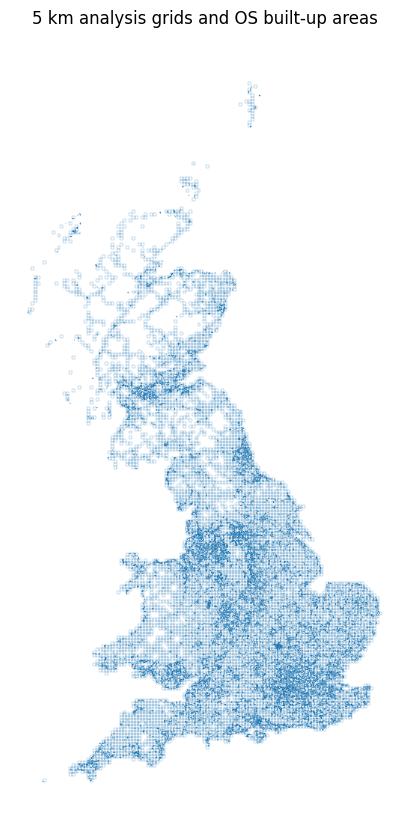

In [177]:
fig, ax = plt.subplots(
    figsize=(8, 10)
)

grid_persistence.boundary.plot(
    ax=ax,
    linewidth=0.15
)

places_gdf.boundary.plot(
    ax=ax,
    linewidth=0.1
)

ax.set_title(
    "5 km analysis grids and OS built-up areas"
)

ax.set_axis_off()

plt.show()

## 12. Decide how I will assign a place to a grid

A 5 km grid can overlap more than one settlement. Using only the grid centroid could miss a settlement that occupies a large part of the grid.

So I am using a slightly better rule:

> For each 5 km grid, assign the named built-up area that has the **largest polygon overlap** with that grid.

This does not say that the entire settlement is a hotspot. It only gives the grid a readable location label.

## 13. Find grid and place polygons that intersect

First I use a spatial join to find candidate overlaps. This is more efficient than comparing every grid with every place polygon.

In [178]:
grid_for_match = (
    grid_persistence[
        [
            "grid_id",
            "geometry"
        ]
    ]
    .copy()
)

grid_for_match[
    "grid_id"
] = (
    grid_for_match[
        "grid_id"
    ]
    .astype(str)
)

place_for_match = (
    places_gdf[
        [
            "place_code",
            "place_name",
            "geometry"
        ]
    ]
    .copy()
)

candidate_matches = gpd.sjoin(
    grid_for_match,
    place_for_match,
    how="left",
    predicate="intersects"
)

print(
    "Candidate grid-place matches:",
    len(candidate_matches)
)

candidate_matches[
    [
        "grid_id",
        "place_name",
        "index_right"
    ]
].head(20)

Candidate grid-place matches: 17750


,grid_id,place_name,index_right
0,R000_C005,Old Town,7650.0
0,R000_C005,Hugh Town,838.0
1,R000_C021,Lizard,5246.0
1,R000_C021,Ruan Minor,3363.0
2,R001_C020,Mullion Cove,3167.0
2,R001_C020,Mullion,3166.0
3,R001_C021,Ruan Minor,3363.0
4,R001_C022,Coverack,424.0
5,R002_C014,NaN,NaN
6,R002_C015,NaN,NaN


## 14. Calculate the actual overlap area

For every grid-place candidate, I calculate the intersection area in square metres.

If a grid overlaps several named places, the place with the largest overlap will be selected.

In [179]:
def calculate_overlap_area(row):

    place_index = row[
        "index_right"
    ]

    if pd.isna(place_index):
        return 0.0

    place_geometry = (
        places_gdf.loc[
            int(place_index),
            "geometry"
        ]
    )

    return (
        row.geometry
        .intersection(
            place_geometry
        )
        .area
    )


candidate_matches[
    "overlap_area_m2"
] = (
    candidate_matches.apply(
        calculate_overlap_area,
        axis=1
    )
)

candidate_matches[
    "overlap_area_km2"
] = (
    candidate_matches[
        "overlap_area_m2"
    ]
    / 1_000_000
)

candidate_matches[
    [
        "grid_id",
        "place_name",
        "overlap_area_km2"
    ]
].head(20)

,grid_id,place_name,overlap_area_km2
0,R000_C005,Old Town,0.215625
0,R000_C005,Hugh Town,0.515000
1,R000_C021,Lizard,0.446875
1,R000_C021,Ruan Minor,0.028750
2,R001_C020,Mullion Cove,1.446250
2,R001_C020,Mullion,0.896250
3,R001_C021,Ruan Minor,0.271875
4,R001_C022,Coverack,0.227500
5,R002_C014,NaN,0.000000
6,R002_C015,NaN,0.000000


## 15. Select the main named place for each grid

I sort each grid's candidate places by overlap area and keep the largest one.

If the maximum overlap is zero, the grid is treated as outside the named OS built-up areas.

In [180]:
best_place_per_grid = (
    candidate_matches
    .sort_values(
        [
            "grid_id",
            "overlap_area_m2"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "grid_id",
        keep="first"
    )
    [
        [
            "grid_id",
            "place_code",
            "place_name",
            "overlap_area_m2",
            "overlap_area_km2"
        ]
    ]
    .copy()
)

best_place_per_grid[
    "place_name"
] = (
    best_place_per_grid[
        "place_name"
    ]
    .where(
        best_place_per_grid[
            "overlap_area_m2"
        ] > 0
    )
)

best_place_per_grid[
    "place_code"
] = (
    best_place_per_grid[
        "place_code"
    ]
    .where(
        best_place_per_grid[
            "overlap_area_m2"
        ] > 0
    )
)

best_place_per_grid.head(20)

,grid_id,place_code,place_name,overlap_area_m2,overlap_area_km2
0,R000_C005,E63021481,Hugh Town,515000.0,0.515000
1,R000_C021,E63021480,Lizard,446875.0,0.446875
2,R001_C020,E63021478,Mullion Cove,1446250.0,1.446250
3,R001_C021,E63021479,Ruan Minor,271875.0,0.271875
4,R001_C022,E63021477,Coverack,227500.0,0.227500
5,R002_C014,NaN,NaN,0.0,0.000000
6,R002_C015,NaN,NaN,0.0,0.000000
7,R002_C020,E63021472,Rose-in-the-bush,215000.0,0.215000
8,R002_C021,E63021474,Traboe,710625.0,0.710625
9,R002_C022,E63021475,St Keverne,258750.0,0.258750


## 16. Calculate how much of the grid is covered by its main named place

The analysis cells are approximately 25 km², but I calculate the percentage from the actual stored geometry rather than hard-coding 25.

In [181]:
grid_areas = (
    grid_for_match[
        [
            "grid_id",
            "geometry"
        ]
    ]
    .copy()
)

grid_areas[
    "grid_area_m2"
] = (
    grid_areas.geometry.area
)

grid_areas = (
    grid_areas[
        [
            "grid_id",
            "grid_area_m2"
        ]
    ]
)

best_place_per_grid = (
    best_place_per_grid.merge(
        grid_areas,
        on="grid_id",
        how="left"
    )
)

best_place_per_grid[
    "main_place_overlap_percent"
] = (
    best_place_per_grid[
        "overlap_area_m2"
    ]
    /
    best_place_per_grid[
        "grid_area_m2"
    ]
    * 100
).round(2)

best_place_per_grid[
    [
        "grid_id",
        "place_name",
        "overlap_area_km2",
        "main_place_overlap_percent"
    ]
].head(20)

,grid_id,place_name,overlap_area_km2,main_place_overlap_percent
0,R000_C005,Hugh Town,0.515000,2.06
1,R000_C021,Lizard,0.446875,1.79
2,R001_C020,Mullion Cove,1.446250,5.78
3,R001_C021,Ruan Minor,0.271875,1.09
4,R001_C022,Coverack,0.227500,0.91
5,R002_C014,NaN,0.000000,0.00
6,R002_C015,NaN,0.000000,0.00
7,R002_C020,Rose-in-the-bush,0.215000,0.86
8,R002_C021,Traboe,0.710625,2.84
9,R002_C022,St Keverne,0.258750,1.03


## 17. Handle grids outside named built-up areas

I am deliberately **not assigning the nearest city** to these grids.

If a grid has no overlap with an OS named built-up area, I use:

`Outside named built-up area`

This avoids turning a rural hotspot into an incorrect city hotspot.

A local-authority boundary could later be added as another fallback if I want a wider administrative label.

In [182]:
best_place_per_grid[
    "location_type"
] = (
    best_place_per_grid[
        "place_name"
    ]
    .notna()
    .map(
        {
            True:
            "Named built-up area",

            False:
            "Outside named built-up area"
        }
    )
)

best_place_per_grid[
    "display_location"
] = (
    best_place_per_grid[
        "place_name"
    ]
    .fillna(
        "Outside named built-up area"
    )
)

print(
    best_place_per_grid[
        "location_type"
    ]
    .value_counts()
)

best_place_per_grid[
    [
        "grid_id",
        "display_location",
        "location_type",
        "main_place_overlap_percent"
    ]
].head(20)

location_type
Named built-up area            5718
Outside named built-up area    1888
Name: count, dtype: int64


,grid_id,display_location,location_type,main_place_overlap_percent
0,R000_C005,Hugh Town,Named built-up area,2.06
1,R000_C021,Lizard,Named built-up area,1.79
2,R001_C020,Mullion Cove,Named built-up area,5.78
3,R001_C021,Ruan Minor,Named built-up area,1.09
4,R001_C022,Coverack,Named built-up area,0.91
5,R002_C014,Outside named built-up area,Outside named built-up area,0.00
6,R002_C015,Outside named built-up area,Outside named built-up area,0.00
7,R002_C020,Rose-in-the-bush,Named built-up area,0.86
8,R002_C021,Traboe,Named built-up area,2.84
9,R002_C022,St Keverne,Named built-up area,1.03


## 18. Look at the most common location labels

I want to inspect the actual output rather than assuming which cities or towns are most important.

In [183]:
print(
    best_place_per_grid[
        "display_location"
    ]
    .value_counts()
    .head(30)
)

display_location
Outside named built-up area    1888
Birmingham                       14
Sheffield                        10
Edinburgh                        10
Leeds                            10
Glasgow                           9
Coventry                          9
Leicester                         8
Aberdeen                          8
Milton Keynes                     8
Kingston upon Hull                7
Stoke-on-Trent                    7
Plymouth                          7
Peterborough                      7
Telford                           7
Caerdydd                          7
Warrington                        6
Brighton and Hove                 6
Northampton                       6
Bromley                           6
Manchester                        6
Hartlepool                        6
Oxford                            6
Liverpool                         6
Barnet                            6
Abertawe                          5
Derby                             5
Bradford   

## 19. Merge the place information into the Stage 6 persistence grid

This creates a new object rather than modifying the original `grid_persistence`.

In [184]:
grid_persistence[
    "grid_id"
] = (
    grid_persistence[
        "grid_id"
    ]
    .astype(str)
)

grid_persistence_with_places = (
    grid_persistence.merge(
        best_place_per_grid[
            [
                "grid_id",
                "place_code",
                "place_name",
                "display_location",
                "location_type",
                "overlap_area_km2",
                "main_place_overlap_percent"
            ]
        ],
        on="grid_id",
        how="left"
    )
)

grid_persistence_with_places[
    "display_location"
] = (
    grid_persistence_with_places[
        "display_location"
    ]
    .fillna(
        "Unclassified location"
    )
)

print(
    "Rows before merge:",
    len(grid_persistence)
)

print(
    "Rows after merge:",
    len(
        grid_persistence_with_places
    )
)

print(
    "Missing display locations:",
    grid_persistence_with_places[
        "display_location"
    ].isna().sum()
)

Rows before merge: 7606
Rows after merge: 7606
Missing display locations: 0


## 20. Create grid-centre latitude and longitude for Power BI

Power BI can use latitude and longitude to position each hotspot grid on a map.

I calculate the centroid in British National Grid first and then convert the centroid points to WGS84.

In [185]:
grid_centres = (
    grid_persistence_with_places[
        [
            "grid_id",
            "geometry"
        ]
    ]
    .copy()
)

grid_centres[
    "geometry"
] = (
    grid_centres.geometry
    .centroid
)

grid_centres = (
    grid_centres
    .to_crs(
        epsg=4326
    )
)

grid_centres[
    "grid_longitude"
] = (
    grid_centres.geometry.x
)

grid_centres[
    "grid_latitude"
] = (
    grid_centres.geometry.y
)

grid_persistence_with_places = (
    grid_persistence_with_places
    .merge(
        grid_centres[
            [
                "grid_id",
                "grid_latitude",
                "grid_longitude"
            ]
        ],
        on="grid_id",
        how="left"
    )
)

grid_persistence_with_places[
    [
        "grid_id",
        "display_location",
        "grid_latitude",
        "grid_longitude"
    ]
].head(10)

,grid_id,display_location,grid_latitude,grid_longitude
0,R000_C005,Hugh Town,49.933383,-6.286653
1,R000_C021,Lizard,49.969220,-5.173901
2,R001_C020,Mullion Cove,50.012190,-5.246535
3,R001_C021,Ruan Minor,50.014120,-5.176861
4,R001_C022,Coverack,50.016009,-5.107179
5,R002_C014,Outside named built-up area,50.044607,-5.667835
6,R002_C015,Outside named built-up area,50.046791,-5.598145
7,R002_C020,Rose-in-the-bush,50.057086,-5.249567
8,R002_C021,Traboe,50.059020,-5.179828
9,R002_C022,St Keverne,50.060911,-5.110082


## 21. Inspect the most persistent hotspot locations

If `persistence_score` is available, I sort by it to see where the most persistent grids are located.

In [186]:
view_columns = [
    col for col in [
        "grid_id",
        "display_location",
        "place_name",
        "location_type",
        "main_place_overlap_percent",
        "hotspot_years",
        "persistence_score",
        "persistence_category",
        "pattern_category"
    ]
    if col in (
        grid_persistence_with_places.columns
    )
]

if (
    "persistence_score"
    in grid_persistence_with_places.columns
):

    location_preview = (
        grid_persistence_with_places[
            view_columns
        ]
        .sort_values(
            [
                "persistence_score",
                "main_place_overlap_percent"
            ],
            ascending=[
                False,
                False
            ]
        )
        .head(30)
    )

else:

    location_preview = (
        grid_persistence_with_places[
            view_columns
        ]
        .head(30)
    )

location_preview

,grid_id,display_location,place_name,location_type,main_place_overlap_percent,hotspot_years,persistence_score,persistence_category,pattern_category
4646,R076_C054,Liverpool,Liverpool,Named built-up area,98.83,5,1.0,Persistent hotspot,Persistent
6546,R132_C051,Edinburgh,Edinburgh,Named built-up area,98.71,5,1.0,Persistent hotspot,Persistent
3155,R054_C068,Birmingham,Birmingham,Named built-up area,98.22,5,1.0,Persistent hotspot,Persistent
3228,R055_C068,Birmingham,Birmingham,Named built-up area,97.76,5,1.0,Persistent hotspot,Persistent
4615,R075_C074,Sheffield,Sheffield,Named built-up area,93.58,5,1.0,Persistent hotspot,Persistent
4994,R084_C070,Bradford,Bradford,Named built-up area,93.40,5,1.0,Persistent hotspot,Persistent
3301,R056_C068,Birmingham,Birmingham,Named built-up area,92.52,5,1.0,Persistent hotspot,Persistent
2859,R050_C082,Northampton,Northampton,Named built-up area,92.09,5,1.0,Persistent hotspot,Persistent
6499,R131_C038,Glasgow,Glasgow,Named built-up area,91.64,5,1.0,Persistent hotspot,Persistent
3465,R058_C078,Leicester,Leicester,Named built-up area,89.19,5,1.0,Persistent hotspot,Persistent


## 22. Check the Stage 9 dashboard-ready table

Stage 9 already saved a dashboard table containing 2024 predictions and explainability information.

If that file exists, I will add the place information to it using `grid_id`.

In [187]:
print(
    "Stage 9 dashboard table exists:",
    stage9_dashboard_file.exists()
)

if stage9_dashboard_file.exists():

    stage9_dashboard = pd.read_csv(
        stage9_dashboard_file
    )

    stage9_dashboard[
        "grid_id"
    ] = (
        stage9_dashboard[
            "grid_id"
        ]
        .astype(str)
    )

    print(
        "Stage 9 dashboard rows:",
        len(stage9_dashboard)
    )

    print("\nColumns:")
    print(
        stage9_dashboard.columns.tolist()
    )

    display(
        stage9_dashboard.head()
    )

else:
    stage9_dashboard = None

    print(
        "The Stage 9 dashboard table "
        "was not found. "
        "The grid-level location file "
        "can still be created."
    )

Stage 9 dashboard table exists: True
Stage 9 dashboard rows: 7606

Columns:
['grid_id', 'target_year', 'log_previous_count', 'previous_hotspot', 'target_is_hotspot', 'predicted_hotspot', 'predicted_probability_stage9', 'correct_prediction', 'confusion_type', 'distance_from_0_5']


,grid_id,target_year,log_previous_count,previous_hotspot,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,correct_prediction,confusion_type,distance_from_0_5
0,R000_C005,2024,1.386294,0,0,0,5.908384e-06,True,True negative,0.499994
1,R000_C021,2024,1.098612,0,0,0,8.656296e-07,True,True negative,0.499999
2,R001_C020,2024,1.609438,0,0,0,2.621007e-05,True,True negative,0.499974
3,R001_C021,2024,0.693147,0,0,0,5.776701e-08,True,True negative,0.500000
4,R001_C022,2024,0.000000,0,0,0,5.647919e-10,True,True negative,0.500000


## 23. Add location names to the Stage 9 dashboard table

This is a simple `grid_id` merge. It does not change any predictions or SHAP/model interpretation fields.

In [188]:
if stage9_dashboard is not None:

    dashboard_place_lookup = (
        grid_persistence_with_places[
            [
                "grid_id",
                "display_location",
                "place_name",
                "location_type",
                "main_place_overlap_percent",
                "grid_latitude",
                "grid_longitude"
            ]
        ]
        .copy()
    )

    dashboard_place_lookup[
        "grid_id"
    ] = (
        dashboard_place_lookup[
            "grid_id"
        ]
        .astype(str)
    )

    stage9_dashboard_with_places = (
        stage9_dashboard.merge(
            dashboard_place_lookup,
            on="grid_id",
            how="left"
        )
    )

    print(
        "Rows after merge:",
        len(
            stage9_dashboard_with_places
        )
    )

    print(
        "Missing location labels:",
        stage9_dashboard_with_places[
            "display_location"
        ].isna().sum()
    )

    display(
        stage9_dashboard_with_places.head()
    )

else:

    stage9_dashboard_with_places = None

Rows after merge: 7606
Missing location labels: 0


,grid_id,target_year,log_previous_count,previous_hotspot,target_is_hotspot,predicted_hotspot,predicted_probability_stage9,correct_prediction,confusion_type,distance_from_0_5,display_location,place_name,location_type,main_place_overlap_percent,grid_latitude,grid_longitude
0,R000_C005,2024,1.386294,0,0,0,5.908384e-06,True,True negative,0.499994,Hugh Town,Hugh Town,Named built-up area,2.06,49.933383,-6.286653
1,R000_C021,2024,1.098612,0,0,0,8.656296e-07,True,True negative,0.499999,Lizard,Lizard,Named built-up area,1.79,49.969220,-5.173901
2,R001_C020,2024,1.609438,0,0,0,2.621007e-05,True,True negative,0.499974,Mullion Cove,Mullion Cove,Named built-up area,5.78,50.012190,-5.246535
3,R001_C021,2024,0.693147,0,0,0,5.776701e-08,True,True negative,0.500000,Ruan Minor,Ruan Minor,Named built-up area,1.09,50.014120,-5.176861
4,R001_C022,2024,0.000000,0,0,0,5.647919e-10,True,True negative,0.500000,Coverack,Coverack,Named built-up area,0.91,50.016009,-5.107179


## 24. Save the new grid-level location dataset

I will save both a CSV for Power BI and a GeoPackage in case I want to map the grid polygons again in Python or QGIS.

In [189]:
grid_csv_output = (
    location_output_dir /
    "grid_persistence_5km_with_place_names.csv"
)

grid_gpkg_output = (
    location_output_dir /
    "grid_persistence_5km_with_place_names.gpkg"
)

grid_export = (
    grid_persistence_with_places
    .drop(
        columns="geometry"
    )
)

grid_export.to_csv(
    grid_csv_output,
    index=False
)

if grid_gpkg_output.exists():
    grid_gpkg_output.unlink()

grid_persistence_with_places.to_file(
    grid_gpkg_output,
    layer="grid_persistence_places",
    driver="GPKG"
)

print("Saved CSV:")
print(grid_csv_output)

print("\nSaved GeoPackage:")
print(grid_gpkg_output)

Saved CSV:
/content/drive/MyDrive/disseration/stage9_5_place_names/grid_persistence_5km_with_place_names.csv

Saved GeoPackage:
/content/drive/MyDrive/disseration/stage9_5_place_names/grid_persistence_5km_with_place_names.gpkg


## 25. Save the Stage 9 dashboard table with locations

This file will be useful when I build the predictive/explainability page in Power BI.

In [190]:
if (
    stage9_dashboard_with_places
    is not None
):

    dashboard_output = (
        location_output_dir /
        "stage9_dashboard_explainability_2024_with_place_names.csv"
    )

    stage9_dashboard_with_places.to_csv(
        dashboard_output,
        index=False
    )

    print(
        "Saved Stage 9 dashboard "
        "table with place names:"
    )

    print(dashboard_output)

else:

    dashboard_output = None

    print(
        "No Stage 9 dashboard table "
        "was exported because the "
        "source file was not found."
    )

Saved Stage 9 dashboard table with place names:
/content/drive/MyDrive/disseration/stage9_5_place_names/stage9_dashboard_explainability_2024_with_place_names.csv


## 26. Final checks before moving to Power BI

I want to confirm that the number of grids has not changed and that the location enrichment did not affect the original persistence values.

In [191]:
print("=" * 60)
print(
    "PLACE-NAME CONTINUATION COMPLETED"
)
print("=" * 60)

print(
    "\nOriginal Stage 6 grid rows:",
    len(grid_persistence)
)

print(
    "Rows after adding places:",
    len(
        grid_persistence_with_places
    )
)

print(
    "Unique grid IDs:",
    grid_persistence_with_places[
        "grid_id"
    ].nunique()
)

print(
    "\nNamed built-up-area grids:",
    (
        grid_persistence_with_places[
            "location_type"
        ]
        == "Named built-up area"
    ).sum()
)

print(
    "Outside named built-up areas:",
    (
        grid_persistence_with_places[
            "location_type"
        ]
        == "Outside named built-up area"
    ).sum()
)

print(
    "\nUnique display locations:",
    grid_persistence_with_places[
        "display_location"
    ].nunique()
)

print("\nPower BI grid file:")
print(grid_csv_output)

if dashboard_output is not None:
    print(
        "\nStage 9 explainability "
        "file with places:"
    )
    print(dashboard_output)

print(
    "\nNext step: "
    "Stage 10 - Power BI Dashboard"
)

PLACE-NAME CONTINUATION COMPLETED

Original Stage 6 grid rows: 7606
Rows after adding places: 7606
Unique grid IDs: 7606

Named built-up-area grids: 5718
Outside named built-up areas: 1888

Unique display locations: 4236

Power BI grid file:
/content/drive/MyDrive/disseration/stage9_5_place_names/grid_persistence_5km_with_place_names.csv

Stage 9 explainability file with places:
/content/drive/MyDrive/disseration/stage9_5_place_names/stage9_dashboard_explainability_2024_with_place_names.csv

Next step: Stage 10 - Power BI Dashboard


# My observation

I originally thought I would need an individual collision GeoDataFrame to add place names. After checking the saved outputs from the earlier stages, that was unnecessary for the grid-level hotspot labels.

The Stage 6 `grid_persistence_5km.gpkg` already contains the 5 km hotspot grid geometry and persistence results. I therefore matched those grid polygons directly with the OS Open Built Up Areas dataset.

Where a grid overlaps more than one named settlement, I used the settlement with the largest overlap area. This is more suitable than simply using the grid centroid.

Grids that do not overlap a named built-up area remain labelled as `Outside named built-up area`. I have not automatically assigned them to the nearest city because that could misrepresent rural hotspot locations.

The place name is only a descriptive dashboard label. The actual analytical unit remains the original 5 km grid.